In [1]:
import geopandas as gpd
from folium.plugins import MarkerCluster
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import numpy as np
from sklearn.model_selection import train_test_split, KFold,GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import randint
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from collections import deque

In [2]:
# Fájl elérési útja
csv_path = 'data/crime_data.csv'

# Beolvasás
df = pd.read_csv(csv_path)

# Első pár sor
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13974502,JJ423750,09/21/2025 12:00:00 AM,095XX S CALUMET AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - GARAGE,False,False,...,9.0,49.0,14,1180262.0,1841791.0,2025,09/28/2025 03:42:59 PM,41.721137,-87.615333,"(41.72113678, -87.615333015)"
1,13975969,JJ425352,09/21/2025 12:00:00 AM,031XX S WELLS ST,0710,THEFT,THEFT FROM MOTOR VEHICLE,RESIDENCE,False,False,...,11.0,34.0,06,1175131.0,1884127.0,2025,09/28/2025 03:42:59 PM,41.837427,-87.632864,"(41.837427273, -87.632863567)"
2,13974043,JJ423022,09/21/2025 12:00:00 AM,001XX W LAKE ST,0810,THEFT,OVER $500,SIDEWALK,False,False,...,42.0,32.0,06,1175401.0,1901736.0,2025,09/28/2025 03:42:59 PM,41.885742,-87.631345,"(41.885741529, -87.631344503)"
3,13976000,JJ425621,09/21/2025 12:00:00 AM,050XX N WOLCOTT AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,40.0,4.0,11,1162901.0,1933808.0,2025,09/28/2025 03:42:59 PM,41.974020,-87.676344,"(41.974020487, -87.676344418)"
4,13976430,JJ425187,09/21/2025 12:00:00 AM,021XX S CALUMET AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,HOTEL / MOTEL,False,False,...,3.0,33.0,14,1178840.0,1890202.0,2025,09/28/2025 03:42:59 PM,41.854014,-87.619068,"(41.854013684, -87.619068382)"


# EDA

In [9]:
def treemap(categories,title,path,values):
    fig = px.treemap(categories, path=path, values=values, height=1000, width=1500,
                 title=title, color_discrete_sequence = px.colors.sequential.RdBu)
    fig.data[0].textinfo = 'label+text+value'
    fig.show()



In [10]:
def histogram(data,path,color,title,xaxis,yaxis):
    fig = px.histogram(data, x=path,color=color)
    fig.update_layout(
        title_text=title,
        xaxis_title_text=xaxis,
        yaxis_title_text=yaxis,
        bargap=0.2,
        bargroupgap=0.1
    )
    fig.show()

In [11]:
Number_crimes = df['Primary Type'].value_counts()

categories = pd.DataFrame({
    'Primary Type': Number_crimes.index,
    'values': Number_crimes.values
})
categories['values'] = pd.to_numeric(categories['values'], errors='coerce')
print(categories)
print(categories.head())

                         Primary Type   values
0                               THEFT  1785150
1                             BATTERY  1532491
2                     CRIMINAL DAMAGE   956346
3                           NARCOTICS   763342
4                             ASSAULT   563123
5                       OTHER OFFENSE   524325
6                            BURGLARY   444757
7                 MOTOR VEHICLE THEFT   429681
8                  DECEPTIVE PRACTICE   387055
9                             ROBBERY   314286
10                  CRIMINAL TRESPASS   226310
11                  WEAPONS VIOLATION   124642
12                       PROSTITUTION    70405
13         OFFENSE INVOLVING CHILDREN    60359
14             PUBLIC PEACE VIOLATION    54729
15                        SEX OFFENSE    34126
16                CRIM SEXUAL ASSAULT    27290
17   INTERFERENCE WITH PUBLIC OFFICER    20176
18               LIQUOR LAW VIOLATION    15377
19                           GAMBLING    14663
20           

In [12]:
import pandas as pd
import plotly.express as px

def treemap_with_other(df, category_col, value_col,threshold=0.015):
    tmp = df.copy()
    total = tmp[value_col].sum()
    share = tmp[value_col] / total

    tmp[category_col] = tmp[category_col].where(share >= threshold, "Egyéb")
    tmp = tmp.groupby(category_col, as_index=False)[value_col].sum()
    return tmp




In [25]:
crime_type_hu = {
    "THEFT": "Lopás",
    "BATTERY": "Testi sértés",
    "CRIMINAL DAMAGE": "Rongálás",
    "ASSAULT": "Támadás",
    "DECEPTIVE PRACTICE": "Csalás / megtévesztés",
    "OTHER OFFENSE": "Egyéb bűncselekmény",
    "MOTOR VEHICLE THEFT": "Gépjárműlopás",
    "ROBBERY": "Rablás",
    "BURGLARY": "Betörés",
    "WEAPONS VIOLATION": "Fegyverrel kapcsolatos jogsértés",
    "NARCOTICS": "Kábítószerrel kapcsolatos bűncselekmény",
    "CRIMINAL TRESPASS": "Magánlaksértés / birtokháborítás",
    "OFFENSE INVOLVING CHILDREN": "Gyermekeket érintő bűncselekmény",
    "SEX OFFENSE": "Szexuális bűncselekmény",
    "PUBLIC PEACE VIOLATION": "Közrend megzavarása",
    "CRIMINAL SEXUAL ASSAULT": "Szexuális erőszak",
    "INTERFERENCE WITH PUBLIC OFFICER": "Hivatalos személy akadályozása",
    "ARSON": "Gyújtogatás",
    "HOMICIDE": "Emberölés",
    "PROSTITUTION": "Prostitúció",
    "STALKING": "Zaklatás",
    "INTIMIDATION": "Megfélemlítés",
    "KIDNAPPING": "Emberrablás",
    "CONCEALED CARRY LICENSE VIOLATION": "Rejtett fegyverviselési engedély megsértése",
    "LIQUOR LAW VIOLATION": "Alkoholtörvény megsértése",
    "OBSCENITY": "Szeméremsértés",
    "GAMBLING": "Szerencsejátékhoz kapcsolódó jogsértés",
    "PUBLIC INDECENCY": "Közszeméremsértés",
    "HUMAN TRAFFICKING": "Emberkereskedelem",
    "OTHER": "Egyéb"
}

In [26]:
tmp = treemap_with_other(categories, "Primary Type", "values")

tmp["Bűncselekmény típusa"] = (
    tmp["Primary Type"]
    .map(crime_type_hu)
    .fillna(tmp["Primary Type"])
)

fig = px.treemap(
    tmp,
    path=["Bűncselekmény típusa"],
    values="values",
    title="Főbb bűncselekménytípusok Chicagóban",
    color_discrete_sequence=px.colors.sequential.RdBu
)

fig.data[0].textinfo = "label+text+value"

fig.update_layout(
    title=None,
    margin=dict(t=0, l=0, r=0, b=0)
)

fig.write_image(
    "docs/Szakdolgozat docs/Images/EDA/major_crimes_chicago.svg",
    scale=3
)

In [24]:
tmp = treemap_with_other(categories, 'Primary Type', 'values')
treemap(tmp,'Major Crimes in Chicago',['Primary Type'],'values')
#save it as svg file
fig = px.treemap(tmp, path=['Primary Type'], values='values',
                 title='Major Crimes in Chicago', color_discrete_sequence=px.colors.sequential.RdBu)
fig.data[0].textinfo = 'label+text+value'
fig.update_layout( title=None,
    margin=dict(t=0, l=0, r=0, b=0)
)
fig.write_image("docs/Szakdolgozat docs/Images/EDA/major_crimes_chicago.svg", scale=3)


In [16]:
# Import geojson file for districts
districts_gdf = gpd.read_file("data/PoliceDistrictDec2012_20251008.geojson")
districts_gdf = districts_gdf.drop([':updated_at', ':created_at'], axis=1)
district_crimes = df['District'].value_counts().reset_index()
district_crimes.columns = ['District', 'Crime_Count']
district_crimes['District'] = district_crimes['District'].astype(int)
districts_gdf['dist_num'] = districts_gdf['dist_num'].astype(int)

district_crimes_map = pd.merge(
    districts_gdf,
    district_crimes,
    left_on='dist_num',
    right_on='District',
    how='inner')

In [17]:
# 2. Térkép inicializálása
choropleth_map = folium.Map(location=[41.88, -87.62], zoom_start=10)
folium.Choropleth(
    geo_data=district_crimes_map,
    data=district_crimes_map,
    columns=['District', 'Crime_Count'],
    key_on='feature.properties.dist_num',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Bűncselekmények száma rendőrségi körzetenként'
).add_to(choropleth_map)


folium.GeoJson(
    district_crimes_map,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 1.5}
).add_to(choropleth_map)

choropleth_map.save('chicago_choropleth.html')

choropleth_map


NameError: name 'folium' is not defined

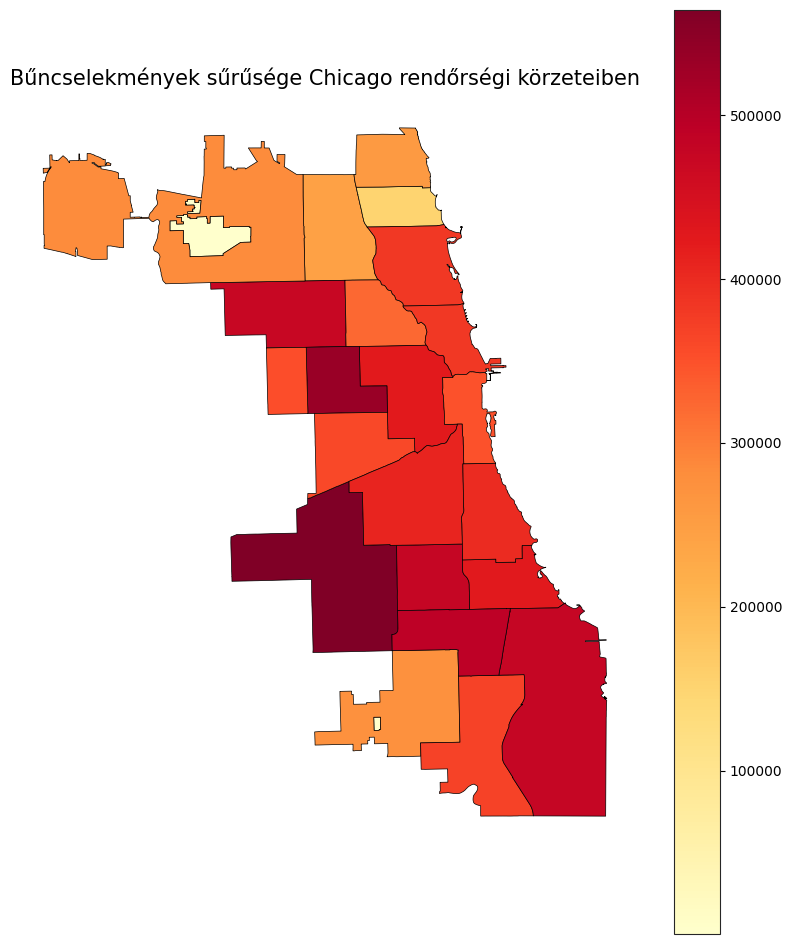

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
district_crimes_map.plot(column='Crime_Count',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/EDA/buneset_suruseg_terkep', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# Create a map visualization of the data
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()],zoom_start=12)
#Visualize the theft crimes from df on the map
theft = df[df['Primary Type'] == 'INTERFERENCE WITH PUBLIC OFFICER']
valid_theft = theft.dropna(subset=['Latitude', 'Longitude'])
marker_cluster = MarkerCluster().add_to(m)
for _, row in valid_theft.iterrows():  # Use valid_theft instead of theft
    folium.Marker(
       location=[row['Latitude'], row['Longitude']],
       popup=str(row['Date'])
    ).add_to(marker_cluster)
m
#save the map
m.save("docs/Szakdolgozat docs/Images/EDA/theft_map.html")


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')


df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month
df['Year_Month'] = df['Date'].dt.to_period('M')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

days_order_hu = [
    'Hétfő', 'Kedd', 'Szerda', 'Csütörtök',
    'Péntek', 'Szombat', 'Vasárnap'
]

df['DayOfWeek_hu'] = pd.Categorical(
    df['Date'].dt.dayofweek.map({
        0: 'Hétfő',
        1: 'Kedd',
        2: 'Szerda',
        3: 'Csütörtök',
        4: 'Péntek',
        5: 'Szombat',
        6: 'Vasárnap'
    }),
    categories=days_order_hu,
    ordered=True
)

crime_heatmap_data = pd.crosstab(df['DayOfWeek_hu'], df['Hour'])
crime_heatmap_data = crime_heatmap_data.reindex(days_order_hu)

/tmp/ipykernel_5277/423351433.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


KeyboardInterrupt: 

In [7]:



plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.heatmap(
    crime_heatmap_data.iloc[::-1],
    cmap='YlOrRd',
    linewidths=.5,
    yticklabels=days_order_hu[::-1]
)

plt.title('Bűncselekmények eloszlása a hét napjai és a nap órái szerint', fontsize=16)
plt.xlabel('Óra (0-23)', fontsize=12, color='black')
plt.ylabel('A hét napja', fontsize=12, color='black')

plt.tight_layout()
plt.savefig(
    'docs/Szakdolgozat docs/Images/EDA/buneset_heti_nap_eloszlása.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

NameError: name 'crime_heatmap_data' is not defined

<Figure size 1200x600 with 0 Axes>

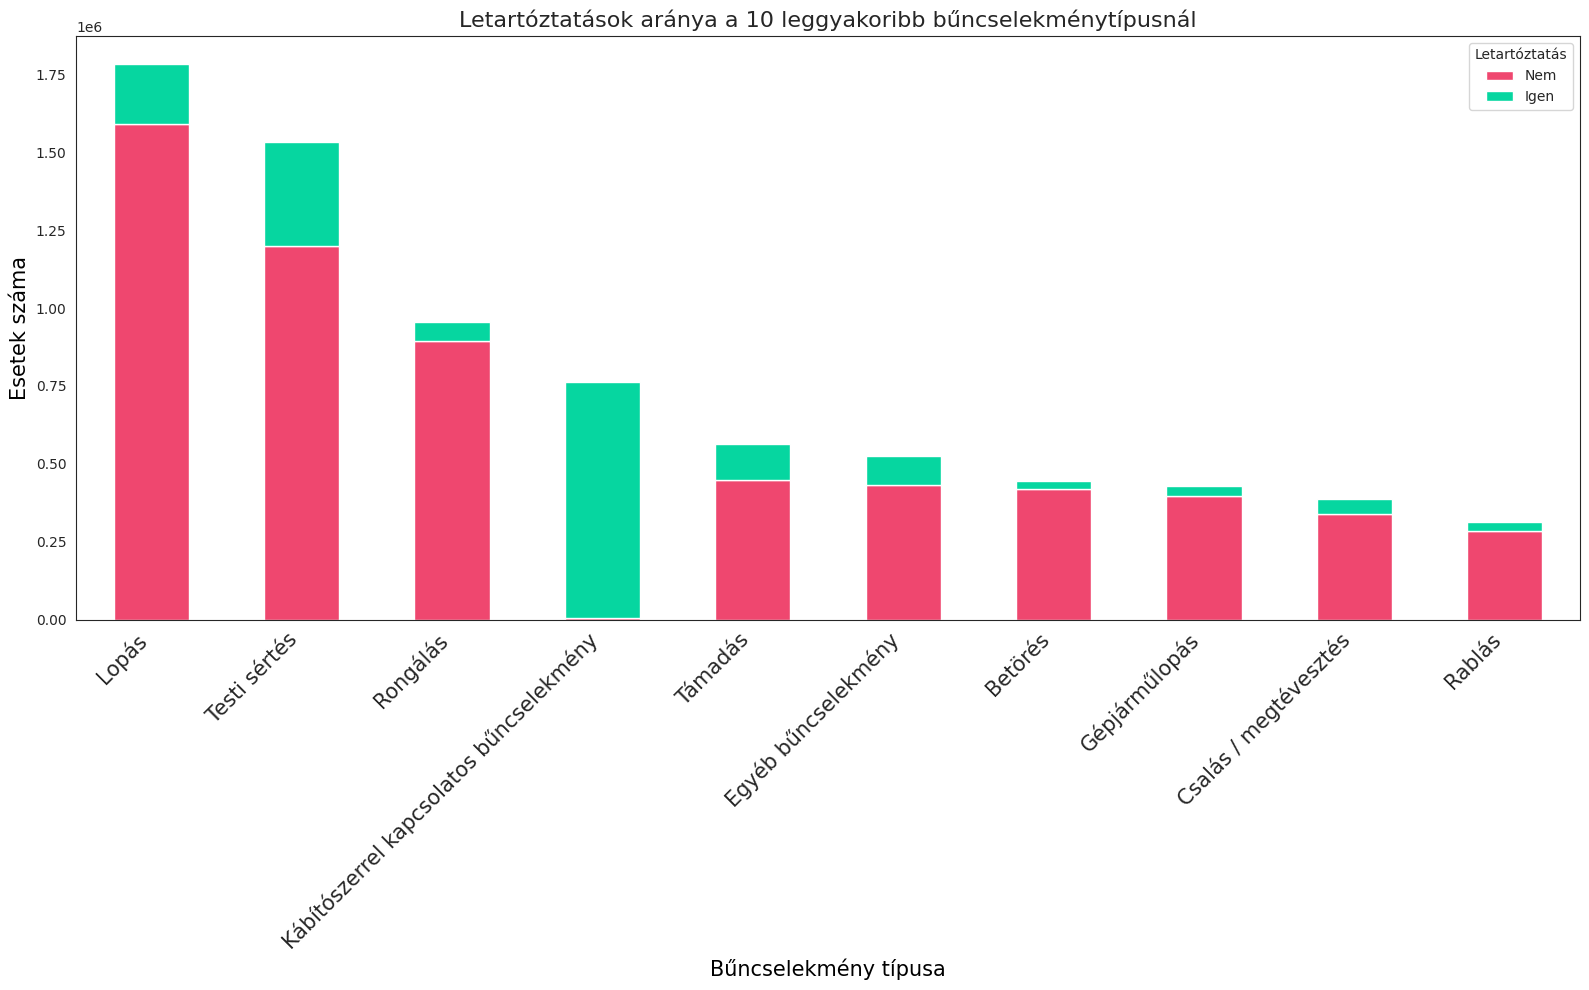

In [22]:
crime_type_hu = {
    "THEFT": "Lopás",
    "BATTERY": "Testi sértés",
    "CRIMINAL DAMAGE": "Rongálás",
    "ASSAULT": "Támadás",
    "DECEPTIVE PRACTICE": "Csalás / megtévesztés",
    "OTHER OFFENSE": "Egyéb bűncselekmény",
    "MOTOR VEHICLE THEFT": "Gépjárműlopás",
    "ROBBERY": "Rablás",
    "BURGLARY": "Betörés",
    "WEAPONS VIOLATION": "Fegyverrel kapcsolatos jogsértés",
    "NARCOTICS": "Kábítószerrel kapcsolatos bűncselekmény"
}

top_10_types = df['Primary Type'].value_counts().nlargest(10).index
df_top10 = df[df['Primary Type'].isin(top_10_types)].copy()

df_top10['Bűncselekmény típusa'] = (
    df_top10['Primary Type']
    .map(crime_type_hu)
    .fillna(df_top10['Primary Type'])
)

arrest_stats = pd.crosstab(
    df_top10['Bűncselekmény típusa'],
    df_top10['Arrest']
)

arrest_stats['Total'] = arrest_stats.sum(axis=1)
arrest_stats = arrest_stats.sort_values('Total', ascending=False).drop('Total', axis=1)

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('white')

arrest_stats.plot(
    kind='bar',
    stacked=True,
    color=['#ef476f', '#06d6a0'],
    ax=ax
)

ax.set_title('Letartóztatások aránya a 10 leggyakoribb bűncselekménytípusnál', fontsize=16)
ax.set_xlabel('Bűncselekmény típusa', fontsize=15, color='black')
ax.set_ylabel('Esetek száma', fontsize=15, color='black')

ax.legend(
    title='Letartóztatás',
    labels=['Nem', 'Igen']
)

plt.xticks(rotation=45, ha='right', fontsize = 15)
plt.tight_layout()

plt.savefig(
    'docs/Szakdolgozat docs/Images/EDA/arrest_stats_top10.svg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
top_10_types = df['Primary Type'].value_counts().nlargest(10).index
df_top10 = df[df['Primary Type'].isin(top_10_types)]

# Kereszttábla a típusok és a letartóztatás (Arrest) között
arrest_stats = pd.crosstab(df_top10['Primary Type'], df_top10['Arrest'])

# Sorba rendezzük a teljes bűncselekményszám alapján (csökkenő)
arrest_stats['Total'] = arrest_stats.sum(axis=1)
arrest_stats = arrest_stats.sort_values('Total', ascending=False).drop('Total', axis=1)

# Ábrázolás
arrest_stats.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ef476f', '#06d6a0'])
fig.patch.set_facecolor('white')
plt.title('Letartóztatások aránya a Top 10 bűncselekménytípusnál', fontsize=16)
plt.xlabel('Bűncselekmény típusa', fontsize=12, color='black')
plt.ylabel('Esetek száma', fontsize=12, color= 'black')
plt.legend(title='Letartóztatás', labels=['Nem (False)', 'Igen (True)'])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('docs/Szakdolgozat docs/Images/EDA/arrest_stats_top10.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))

# Csoportosítás a korábban létrehozott Év-Hónap oszlop alapján
monthly_crimes = df.groupby('Year_Month').size()

# Az indexet stringgé kell alakítani a plotoláshoz (pandas Period index néha trükkös)
monthly_crimes.index = monthly_crimes.index.astype(str)

# Vonaldiagram rajzolása
plt.plot(monthly_crimes.index, monthly_crimes.values, marker='o', linestyle='-', color='#118ab2', markersize=4)
fig.patch.set_facecolor('white')
plt.title('Bűncselekmények számának havi alakulása', fontsize=16)
plt.xlabel('Idő (Év-Hónap)', fontsize=12, color='black')
plt.ylabel('Havi esetszám', fontsize=12, color='black')

# Hogy ne legyen olvashatatlan az X tengely, csak minden 6. vagy 12. hónapot írjuk ki
plt.xticks(monthly_crimes.index[::12], rotation=45)

plt.tight_layout()
plt.savefig('docs/Szakdolgozat docs/Images/EDA/buneset_havi_alakulasa.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Tél'
    elif month in [3, 4, 5]:
        return 'Tavasz'
    elif month in [6, 7, 8]:
        return 'Nyár'
    else:
        return 'Ősz'

# Új oszlop létrehozása az évszakokkal
df['Season'] = df['Month'].apply(get_season)

# Szezonok logikai sorrendjének beállítása (különben ABC sorrendbe tenné az ábrán)
season_order = ['Tavasz', 'Nyár', 'Ősz', 'Tél']

In [ ]:
plt.figure(figsize=(10, 6))

# Összeszámoljuk a bűncselekményeket hónaponként, és sorba rendezzük 1-től 12-ig
monthly_counts = df['Month'].value_counts().sort_index()

# Hónapok nevei a tengelyhez
month_names = ['Jan', 'Feb', 'Már', 'Ápr', 'Máj', 'Jún', 'Júl', 'Aug', 'Szep', 'Okt', 'Nov', 'Dec']

# Ábra elkészítése
sns.barplot(x=month_names, y=monthly_counts.values, palette='coolwarm')
fig.patch.set_facecolor('white')
plt.title('Bűncselekmények összesített száma hónaponként Chicagóban', fontsize=16)
plt.xlabel('Hónap', fontsize=12, color='black')
plt.ylabel('Esetek száma', fontsize=12, color='black')

# Opcionális: értékek ráírása az oszlopok tetejére
for i, v in enumerate(monthly_counts.values):
    plt.text(i, v + (v * 0.01), str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('docs/Szakdolgozat docs/Images/EDA/buneset_havi_alakulasa_osszesitett.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_geo = df.dropna(subset=['Latitude', 'Longitude'])

# 2. Szűrés egy adott évre (pl. 2023) és típusra (pl. MOTOR VEHICLE THEFT)
# Ha a te oszlopaid neve más (pl. 'Year' vagy 'Primary Type'), írd át!
df_hotspot = df_geo[(df_geo['Year'] == 2023) & (df_geo['Primary Type'] == 'MOTOR VEHICLE THEFT')]

In [ ]:
 # Létrehozunk egy szép nagy, négyzetes ábrát (a térképekhez ez illik)
import contextily as cx
fig, ax = plt.subplots(figsize=(12, 12))

# 1. Hőtérkép rajzolása a Seaborn segítségével (KDE Plot)
sns.kdeplot(
    x=df_hotspot['Longitude'],
    y=df_hotspot['Latitude'],
    cmap='Reds',        # Piros hotspotok
    fill=True,          # Legyen kitöltve színnel
    alpha=0.6,          # 60%-os átlátszóság, hogy látszódjon az utcatérkép
    levels=15,          # Sűrűségi szintek (mennyire legyen "gyűrűs")
    thresh=0.05,        # Ne színezze be azokat a részeket, ahol elhanyagolható az esetszám
    ax=ax
)

# 2. Háttértérkép hozzáadása a Contextily-vel
# A crs="EPSG:4326" mondja meg a programnak, hogy mi sima GPS koordinátákat (Lat/Lon) használunk
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

# 3. Címek és formázás
plt.title('Gépjárműlopások hotspotjai Chicagóban (2023)', fontsize=18, pad=20)
plt.xlabel('Hosszúság (Longitude)', fontsize=12)
plt.ylabel('Szélesség (Latitude)', fontsize=12)

# Eltüntetjük a keretet a térkép körül a letisztultabb dizájnhoz
sns.despine(left=True, bottom=True)

# ---------------------------------------------------------
# 4. MENTÉS A SZAKDOLGOZATHOZ (A legfontosabb lépés!)
# ---------------------------------------------------------
# A dpi=300 biztosítja a nyomdai/PDF minőséget.
# A bbox_inches='tight' levágja a felesleges fehér margót a kép széléről.

# Mentheted PNG-ként (ezt könnyű Wordbe húzni):
plt.savefig('chicago_hotspot_2023.png', dpi=300, bbox_inches='tight')

# Vagy mentheted közvetlenül vektorgrafikus PDF-ként is (LaTeX-hez ez a legjobb):
# plt.savefig('chicago_hotspot_2023.pdf', bbox_inches='tight')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
import geopandas as gpd

# ---------------------------------------------------------
# 1. ADATOK ELŐKÉSZÍTÉSE
# ---------------------------------------------------------
# Pontadatok (Hőtérképhez)
df_geo = df.dropna(subset=['Latitude', 'Longitude'])


# Határvonalak (GeoJSON) betöltése
geojson_path = 'data/PoliceDistrictDec2012_20251008.geojson'
districts_gdf = gpd.read_file(geojson_path)

# ---------------------------------------------------------
# 2. ÁBRA LÉTREHOZÁSA
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))

# 1. RÉTEG: A Hőtérkép (KDE Plot)
sns.kdeplot(
    x=df_geo['Longitude'],
    y=df_geo['Latitude'],
    cmap='Reds',
    fill=True,
    alpha=0.6,
    levels=15,
    thresh=0.05,
    ax=ax               # Rárajzoljuk az 'ax' vászonra
)

# 2. RÉTEG: A Kerületek/Körzetek határvonalai
# A facecolor='none' biztosítja, hogy a poligonok ne takarják el a hőtérképet, csak a körvonaluk látszódjon.
districts_gdf.plot(
    ax=ax,                  # Ugyanarra az 'ax' vászonra rajzoljuk!
    facecolor='none',       # Átlátszó belső
    edgecolor='black',      # Fekete határvonal
    linewidth=1.2,          # Vonalvastagság
    alpha=0.8               # Vonalak enyhe átlátszósága, hogy ne legyenek túl tolakodóak
)

# 3. RÉTEG: Az utcatérkép a háttérben
# Fontos: A crs="EPSG:4326" mondja meg, hogy GPS koordinátákat használunk
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

# ---------------------------------------------------------
# 3. CÍMEK ÉS MENTÉS
# ---------------------------------------------------------
plt.title('Gépjárműlopások hotspotjai a rendőrségi körzetek tükrében (2023)', fontsize=16, pad=20)
plt.xlabel('Hosszúság (Longitude)', fontsize=12)
plt.ylabel('Szélesség (Latitude)', fontsize=12)

# Keret eltüntetése a letisztultabb dizájnhoz
sns.despine(left=True, bottom=True)

# Mentés nyomdai minőségben
plt.savefig('chicago_hotspot_with_boundaries.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
plt.figure(figsize=(12, 7))

# Kiválasztjuk a 4 leggyakoribb bűncselekménytípust
top4_crimes = df['Primary Type'].value_counts().nlargest(4).index

# Kiszűrjük az adatbázist, hogy csak ez a 4 típus maradjon benne
df_top4 = df[df['Primary Type'].isin(top4_crimes)]

# Csoportosított oszlopdiagram (countplot)
# A 'hue' paraméter bontja szét az oszlopokat bűncselekménytípusok szerint
sns.countplot(data=df_top4,
              x='Season',
              hue='Primary Type',
              order=season_order,
              palette='Set2')

plt.title('A leggyakoribb bűncselekmények megoszlása évszakonként', fontsize=16)
plt.xlabel('Évszak', fontsize=12)
plt.ylabel('Esetek száma', fontsize=12)

# Jelmagyarázat elhelyezése
plt.legend(title='Bűncselekmény típusa', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Főbb bűncselekmények megjelenítése kerületenként

In [ ]:
district_crimes = df.groupby(['District', 'Primary Type']).size().reset_index(name='count')
district_crimes

In [ ]:
fig = px.bar(district_crimes,
             x='District',
             y='count',
             color='Primary Type',
             title='Főbb bűncselekmények eloszlása kerületenként',
             labels={'District': 'Kerület', 'count': 'Bűncselekmények száma',
                     'Primary Type': 'Bűncselekmény típusa'},
             height=600)
fig.update_layout(xaxis_type='category')
fig.show()
fig.write_image("Images/EDA/crimes_by_district.svg")

In [ ]:
top_crimes = categories.head(10)['Primary Type'].tolist()
district_top_crimes = df[df['Primary Type'].isin(top_crimes)].groupby(
    ['District', 'Primary Type']).size().reset_index(name='count')

fig = px.sunburst(district_top_crimes,
                  path=['District', 'Primary Type'],
                  values='count',
                  title='Top 10 bűncselekmény kerületenként',
                  height=800)
fig.show()
fig.write_image("Images/EDA/top_crimes.svg")


# Predict the daily number of crimes per month in 2025 using the using data from 2001-2024

## 1. Prepare data

In [ ]:
#create new df
data_reduced = df[['ID','District','Primary Type','Date', 'Latitude', 'Longitude']].copy()
#Split the date to determine year and month
data_reduced['Year'] = df['Date'].str.split("/", expand=True)[2].str.split(" ", expand=True)[0]
data_reduced['Month'] = df['Date'].str.split("/", expand=True)[0]



In [ ]:
#Count how many crime happened in each month in each year in each district
Number_crimes_sum = data_reduced.groupby(['District','Year','Month']).size().reset_index(name='count')
#Calculate the number of crimes per day in the month
Number_crimes_sum['Number_of_days_in_month'] = Number_crimes_sum.apply(
    lambda row: calendar.monthrange(int(row['Year']), int(row['Month']))[1],
    axis=1)

Number_crimes_sum['Number of Crimes Per Day'] = Number_crimes_sum['count'] / Number_crimes_sum['Number_of_days_in_month']
Number_crimes_sum['Year'] = pd.to_numeric(Number_crimes_sum['Year'])
Number_crimes_sum['Month'] = Number_crimes_sum['Month'].astype(int)


In [ ]:
# The training data will be 2001-2024 and we will predict to 2025
Traning_data = Number_crimes_sum[Number_crimes_sum['Year'].between(2001, 2024)]
Traning_data =Traning_data.drop(['Number_of_days_in_month', 'count'], axis=1)
Traning_data = Traning_data[Traning_data['District'] != 21]
Traning_data = Traning_data[Traning_data['District'] != 31]
X = Traning_data.drop(['Number of Crimes Per Day'], axis=1).copy()
Y = Traning_data['Number of Crimes Per Day'].copy()
districts = Traning_data['District'].unique()

In [ ]:
#We will predict to 2025
Test_data = Number_crimes_sum[(Number_crimes_sum['Year'] == 2025)]
Test_data = Test_data[Test_data['District'] != 21]
Test_data = Test_data[Test_data['District'] != 31]
Test_data = Test_data[Test_data['Month'] != 9]
Test_data = Test_data.drop(['Number_of_days_in_month', 'count'], axis=1)
Y_check = Test_data['Number of Crimes Per Day']
#Test_data = Test_data.drop(['Number of Crimes Per Day'], axis=1)

## 1.2 Fill the missing month data with KNN Mean imputer

In [ ]:
#Find the missing month data for each district in each year in the training data
all_months = set(range(1, 13))
missing_data = []
for (district, year), group in X.groupby(['District', 'Year']):
    existing_months = set(group['Month'].astype(int).unique())
    missing_months = all_months - existing_months
    for month in missing_months:
        missing_data.append({'District': district, 'Year': year, 'Month': month})
missing_df = pd.DataFrame(missing_data)


## 1.3 Visualize the data

In [ ]:
# Visualize the Number of Crimes per district for each year in the training data
districts = Traning_data['District'].unique()
plot_data = Traning_data.copy()
plot_data['Year_Str'] = plot_data['Year'].astype(str)
for district in districts:
    district_data = plot_data[plot_data['District'] == district]

    fig = px.line(
        district_data,
        x='Month',
        y='Number of Crimes Per Day',
        color='Year_Str', # Az éveket a szín különbözteti meg
        title=f'Bűncselekmények száma a {district} kerületben évente',
        labels={'Number of Crimes Per Day': 'Bűncselekmények száma', 'Month': 'Hónap'},
        markers=True,
        line_shape='linear' # Egyenes vonalakat garantál a pontok között
    )

    fig.update_xaxes(dtick=1) # X tengelyen csak egész számok (hónapok)
    fig.update_layout(hovermode="x unified") # Kellemesebb interaktív élmény


    fig.show() # Megjeleníti az ábrát


# 2. Build Random Forest model

In [ ]:
# Use Random Forest model to predict

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_train)
print(model.score(X_train,y_train))



In [ ]:
# Calculate RMSE, MAPE, Accuracy of the model
predictions = model.predict(X_train)
MSE = mean_squared_error(y_train, predictions)
RMSE = np.sqrt(MSE)
errors = abs(predictions - y_train)
MAPE = np.mean(100 * (errors / y_train))
Accuracy = 100 - MAPE
print('RMSE of the model:', RMSE)
print('MAPE of the model:', MAPE)
print('Accuracy of the model:', Accuracy, '%')

In [ ]:
sns.scatterplot(x=y_train, y=y_pred)
plt.xlabel("Valós értékek")
plt.ylabel("Prediktált értékek")
plt.title("Valós vs. Prediktált értékek - Random Forest Regresszor")
plt.show()


train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Test score")
plt.legend()
plt.title("Learning curve - Random Forest")
plt.xlabel("Train minták száma")
plt.ylabel("Pontosság / R²")
plt.show()

### 2.1. Hyperparameter tuning

In [ ]:
#Hyperparameter tuning using GridSearchCV if the files are not exist
if not os.path.exists('parameters/best_param.txt') or not os.path.exists('parameters/best_estimator.txt'):
    from sklearn.model_selection import GridSearchCV
    param = {
        'n_estimators': [10, 25, 80, 100, 1000],
        'max_features': [5, 10],
        'max_depth': [None, 10, 80, 90, 100],
        'bootstrap': [True, False]
    }
    grid_search = GridSearchCV(param_grid=param, estimator=model, cv=10, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)

    print(grid_search.best_params_)
    print(grid_search.best_estimator_)
    best_param = grid_search.best_params_
    best_estimator = grid_search.best_estimator_
    # Save the best_param to a txt file and save the txt file to the same folder as the notebook
    with open('parameters/best_param.txt', 'w') as f:
        f.write(str(best_param))
        f.close()
    # Save the best_estimator to a txt file and save the txt file to the same folder as the notebook
    with open('parameters/best_estimator.txt', 'w') as f:
        f.write(str(best_estimator))
        f.close()
else:
    #Read the best_param file
    with open('parameters/best_param.txt', 'r') as f:
        best_param = eval(f.read())
        f.close()

    #Read the best_estimator file
    with open('parameters/best_estimator.txt', 'r') as f:
        best_estimator = eval(f.read())
        f.close()

In [ ]:
#Calculate the accuracy and RMSE of the model
best_estimator.fit(X_train, y_train)
y_pred_gridbest = best_estimator.predict(X_train)
#y_pred_gridbest = grid_search.best_estimator_.predict(X_train)
#RMSE
MSE = mean_squared_error(y_train, y_pred_gridbest)
RMSE = np.sqrt(MSE)
print('RMSE of the model:', RMSE)
#Accuracy
errors = abs(y_pred_gridbest - y_train)
MAPE = np.mean(100 * (errors / y_train))
Accuracy = 100 - MAPE
print('Accuracy of the model:', Accuracy, '%')

In [ ]:
#Hyperparameter tuning using RandomizedSearchCV
if not os.path.exists('parameters/best_param_random.txt') or not os.path.exists('parameters/best_estimator_random.txt'):
    param_random = {
        'n_estimators': [int(x) for x in np.linspace(start = 10, stop = 200, num = 5)],
        'max_features': range(1, 11),
        'max_depth': [int(x) for x in np.linspace(1, 100, num = 3)],
        'bootstrap': [True, False]
    }
    random_search = RandomizedSearchCV(model, param_random, n_iter=10, cv=10, verbose=1, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')

    random_search.fit(X_train, y_train)
    print(random_search.best_params_)
    print(random_search.best_estimator_)
    best_param_random = random_search.best_params_
    best_estimator_random = random_search.best_estimator_
    # Save the best_param to a txt file and save the txt file to the same folder as the notebook
    with open('parameters/best_param_random.txt', 'w') as f:
        f.write(str(best_param_random))
        f.close()
    # Save the best_estimator to a txt file and save the txt file to the same folder as the notebook
    with open('parameters/best_estimator_random.txt', 'w') as f:
        f.write(str(best_estimator_random))
        f.close()
else:
    #Read the best_param file
    with open('parameters/best_param_random.txt', 'r') as f:
        best_param_random = eval(f.read())
        f.close()

    #Read the best_estimator file
    with open('parameters/best_estimator_random.txt', 'r') as f:
        best_estimator_random = eval(f.read())
        f.close()

In [ ]:
#Calculate the accuracy and RMSE of the model
best_estimator_random.fit(X_train, y_train)
y_pred_randombest = best_estimator_random.predict(X_train)
#y_pred_randombest = random_search.best_estimator_.predict(X_train)
#RMSE
MSE = mean_squared_error(y_train, y_pred_randombest)
RMSE = np.sqrt(MSE)
print('RMSE of the model:', RMSE)
#Accuracy
errors = abs(y_pred_randombest - y_train)
MAPE = np.mean(100 * (errors / y_train))
Accuracy = 100 - MAPE
print('Accuracy of the model:', Accuracy, '%')

### 2.2 Feature importance

In [ ]:
#Feature Importance
feature_importance = pd.DataFrame({})
feature_importance['feature'] = X_train.columns
feature_importance['importance'] = best_estimator.feature_importances_
#Visualize the feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance - Random Forest')


### 2.3 Final Model

In [ ]:
#using the best parameters on test data
final_model = RandomForestRegressor(**best_param, random_state=42)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

#RMSE
MSE = mean_squared_error(y_test, y_pred_final)
RMSE = np.sqrt(MSE)
print('RMSE of the model:', RMSE)
#Accuracy
errors = abs(y_pred_final - y_test)
MAPE = np.mean(100 * (errors / y_test))
Accuracy = 100 - MAPE
print('Accuracy of the model:', Accuracy, '%')


### 2.4 Use the final model to predict data for 2025

In [ ]:
#Use on 2025 data
y_pred_check = final_model.predict(Test_data)
#RMSE
MSE = mean_squared_error(Y_check, y_pred_check)
RMSE = np.sqrt(MSE)
print('RMSE of the model:', RMSE)
#Accuracy
errors = abs(y_pred_check - Y_check)
MAPE = np.mean(100 * (errors / Y_check))
Accuracy = 100 - MAPE
print('Accuracy of the model:', Accuracy, '%')
#Visualize the results of the prediction
plt.scatter(y_pred_check, Y_check)



# 3. Use the previous month data to predict the next month

Summary: we want to predict the number of crimes in a month using the previous few month data to predict the next month. In that way we build a time series model.

### 3.1 Functions

In [ ]:
def create_lagged_features(df, col, lag=1):
    df_lagged = df.copy()
    for i in range(1, lag + 1):
        df_lagged[f'{col} Lag {i}'] = df_lagged.groupby('District')[col].shift(i)
    return df_lagged

In [ ]:
def rolling_mean(df, idopontok):
    for i in idopontok:
       df[f'Rolling Mean {i}'] = (
        df.groupby('District')['Number of Crimes Per Day'].transform(lambda s: s.shift(1).rolling(window=i).mean()))

    return df

In [ ]:
#def the rolling standard deviation calculation
def rolling_std(df, idopontok):
    for i in idopontok:
        df[f'Rolling Std {i}'] = (df.groupby('District')['Number of Crimes Per Day'].transform(lambda s: s.shift(1).rolling(window=i).std()))

    return df

In [ ]:
def multi_output_walk_forward_validation(X, y_lagged, model, n_splits=5):
    """
    Walk-forward validációt végez egy többkimenetű regressziós modellhez.

    Args:
        X (pd.DataFrame): A bemeneti jellemzők.
        y (pd.DataFrame): A többkimenetű célváltozók.
        model: A tanítandó modell.
        n_splits (int): A walk-forward felosztások száma.

    Returns:
        tuple: Egy tuple, amely tartalmazza:
            - pd.DataFrame: Egy DataFrame a valós és prediktált értékekkel.
            - list: Az egyes iterációk RMSE értékeinek listája.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores = []
    mape_scores = []
    all_results = []

    print(f"Walk-forward validáció futtatása {n_splits} felosztással...")

    for i, (train_index, test_index) in enumerate(tscv.split(X)):
        print(f"  Split {i + 1}/{n_splits}...")
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_lagged.iloc[train_index], y_lagged.iloc[test_index]

        model.fit(X_train, y_train)
        y_pred_array = model.predict(X_test)

        y_pred = pd.DataFrame(y_pred_array, index=y_test.index, columns=y_test.columns)

        # RMSE számítása az aktuális splitre
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        rmse_scores.append(rmse)
        #MAPE caculation
        errors = abs(y_test.values - y_pred.values)
        MAPE = np.mean(100 * (errors / y_test))
        mape_scores.append(MAPE)

        # Eredmények tárolása
        result_split = pd.concat([
            y_test.add_prefix('Actual_'),
            y_pred.add_prefix('Predicted_')
        ], axis=1)
        all_results.append(result_split)

    print("A validáció befejeződött.")
    final_results_df = pd.concat(all_results)

    return final_results_df, rmse_scores, mape_scores

In [ ]:
def convert_to_sin(df,col):
    df[col] = df[col].astype(float)
    df[f"{col}_Sin"] = df[col].apply(lambda x: (np.sin(((x-1) * 2 * np.pi / 12)+0.5)+1)/2)
    return df

In [ ]:
def year_indexing(df):
    df['Year_Index'] = 2025 - df['Year'] + 1
    return df

In [ ]:
def prepare_month_data(df, col):
    df[col] = df[col].astype(float)
    df[f"{col}_Sin"] = df[col].apply(lambda x: (np.sin(((x-1) * 2 * np.pi / 12)+0.5)+1)/2)
    df[f"{col}_Cos"] = df[col].apply(lambda x: (np.cos(((x-1) * 2 * np.pi / 12)+0.5)+1)/2)
    df['Is_Winter'] = df['Month'].isin([12, 1, 2]).astype(int)
    df['Is_Summer'] = df['Month'].isin([6, 7, 8]).astype(int)
    df = year_indexing(df)
    return df

In [ ]:
def prediction_columns(df, col_name, N_forecast, features):
    target_cols = []
    for i in range(1, N_forecast + 1):
        new_col = f'jovo_{i}_honap'
        df[new_col] = df.groupby('District')[col_name].shift(-i)
        target_cols.append(new_col)
    df = df.dropna()
    X = df[features]
    y = df[target_cols]
    return X, y

In [ ]:
def Prediction(df1, df, model, Y_test, features):
    Predicton_Results = df1[['District', 'Month']].copy()
    predictions = []
    for dist in districts:
        district_rows = df[df['District'] == dist]
        district_rows = district_rows[features]
        Y_pred = model.predict(district_rows.dropna())[0]
        predictions.extend(Y_pred)
        Predicton_Results.loc[Predicton_Results['District'] == dist, 'Predicted'] = Y_pred
    Predicton_Results['Actual'] = Y_test.values
    #Also Calculate the RMSE, MAPE, Accuracy here
    prediction = Predicton_Results['Predicted']
    MSE = mean_squared_error(Y_test, prediction)
    RMSE = np.sqrt(MSE)
    errors = abs(prediction - Y_test)
    MAPE = np.mean(100 * (errors / Y_test))
    MAE = np.mean(abs(errors))
    SD_Of_Errors = np.std(errors)
    SD_Of_APE = np.std(errors / Y_test)
    Accuracy = 100 - MAPE
    print('RMSE of the lagged predictions:', RMSE)
    print('Accuracy of the model:', Accuracy, '%')
    print('Standard Deviation of the errors:', SD_Of_Errors)
    print('Standard Deviation of the APE:', SD_Of_APE)

    return Predicton_Results, RMSE, Accuracy, SD_Of_Errors, SD_Of_APE, MAPE,MAE

In [ ]:
def calculate_RMSE_MAPE(df):
    prediction = df['Predicted']
    actual = df['Actual']
    MSE = mean_squared_error(actual, prediction)
    RMSE = np.sqrt(MSE)
    errors = abs(prediction - actual)
    MAE = np.mean(abs(errors))
    MAPE = np.mean(100 * (errors / actual))
    SD_Of_Errors = np.std(errors)
    SD_Of_APE = np.std(errors / actual)
    Accuracy = 100 - MAPE
    print('RMSE of the lagged predictions:', RMSE)
    print('Accuracy of the model:', Accuracy, '%')
    print('Standard Deviation of the errors:', SD_Of_Errors)
    print('Standard Deviation of the APE:', SD_Of_APE)
    metrics = {
        'RMSE': RMSE,
        'MAE': MAE,
        'MAPE': MAPE,
        'Accuracy': Accuracy
    }
    return metrics

In [ ]:
def visualize_predictionresults(df):
    district_rows_vis = []
    for dist in districts:
        district_rows_vis = df[df['District'] == dist]
        plt.figure(figsize=(10, 6))
        plt.plot(district_rows_vis['Month'], district_rows_vis['Actual'], label='Actual', marker='o')
        plt.plot(district_rows_vis['Month'], district_rows_vis['Predicted'], label='Predicted', marker='x')
        plt.title(f'District {dist} - Actual vs Predicted Crimes Per Day')
        plt.xlabel('Month')
        plt.ylabel('Crimes Per Day')
        plt.legend()
    plt.show()

### 3.2 Use only the previous month data

#### 3.2.1 Prepare the traning data

In [ ]:
N_LAGS = 2
Traning_data_lagged = create_lagged_features(Traning_data, 'Number of Crimes Per Day', N_LAGS)
Traning_data_lagged.dropna(inplace=True)

In [ ]:
#Convert the month column to float
Traning_data_lagged['Month'] = Traning_data_lagged['Month'].astype(float)
# Month sin
Traning_data_lagged = convert_to_sin(Traning_data_lagged, col='Month')
Traning_data_lagged['Month_Cos'] = np.cos(2 * np.pi * Traning_data_lagged['Month'] / 12)
Traning_data_lagged['Is_Winter'] = Traning_data_lagged['Month'].isin([12, 1, 2]).astype(int)
Traning_data_lagged['Is_Summer'] = Traning_data_lagged['Month'].isin([6, 7, 8]).astype(int)
#Drop the month
Traning_data_lagged.drop('Month', axis=1, inplace=True)
Traning_data_lagged = year_indexing(Traning_data_lagged)

#### 3.2.2 Prepare the training data with lagged features

In [ ]:
features_lagged = ['District', 'Year_Index','Month_Sin','Month_Cos','Is_Winter', 'Is_Summer'] + [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS + 1)]
X_lagged, y_Lagged = prediction_columns(Traning_data_lagged, 'Number of Crimes Per Day',8, features_lagged)

#### 3.2.3 Prepare the test data with lagged features

In [ ]:
from collections import deque

districts = Traning_data_lagged['District'].unique()
# delete district 21 and 31 from the districts list
districts = [d for d in districts if d not in [21, 31]]
# 1. Töltsük fel a "memóriát" a legutolsó 12 valós adattal (2024-ből)
history_queues = {}
N_LAGS = 2 # Ahány lag jellemzőt használt a modelled

for district in districts:
    # A tanító adatok utolsó 12 hónapját vesszük minden körzethez
    initial_history = Traning_data_lagged[Traning_data_lagged['District'] == district].tail(N_LAGS)['Number of Crimes Per Day'].tolist()
    history_queues[district] = deque(initial_history, maxlen=N_LAGS)

lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
for c in lag_cols:
    Test_data_lagged = Test_data.copy()
    Test_data_lagged[c] = np.nan
# append the history to the test data for each district but just for the first month

for district in districts:
    district_rows = Test_data_lagged[Test_data_lagged['District'] == district].sort_values('Month')
    first_idx = district_rows.index[0]
    #prepare lag values: history_queues stores oldest->newest, we need lag1 = most recent
    hist_list = list(history_queues[district])
    lags_for_row = hist_list[::-1]
    for i in range(N_LAGS):
        Test_data_lagged.at[first_idx, lag_cols[i]] = lags_for_row[i]



In [ ]:
#Drop the districts we do not use
Test_data_lagged['Month'] = Test_data_lagged['Month'].astype(float)
# Month sin
Test_data_lagged = convert_to_sin(Test_data_lagged, col='Month')
Test_data_lagged['Month_Cos'] = np.cos(2 * np.pi * Test_data_lagged['Month'] / 12)
Test_data_lagged['Is_Winter'] = Test_data_lagged['Month'].isin([12, 1, 2]).astype(int)
Test_data_lagged['Is_Summer'] = Test_data_lagged['Month'].isin([6, 7, 8]).astype(int)
Test_data_lagged = year_indexing(Test_data_lagged)


#### 3.2.4 Hyperparameter tuning with lagged features

In [ ]:
#Hyperparameter tuning with GridSearchCV
model = RandomForestRegressor(random_state=42)
param = {
        'n_estimators': [10, 25, 80, 100, 1000],
        'max_features': [5, 10],
        'max_depth': [None, 10, 80, 90, 100],
        'bootstrap': [True, False]
    }
grid_search = GridSearchCV(param_grid=param, estimator=model, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_lagged, y_Lagged)

print(grid_search.best_params_)
print(grid_search.best_estimator_)
best_param_lagged = grid_search.best_params_
best_estimator_lagged = grid_search.best_estimator_

In [ ]:
#Hyperparameter tuning with RandomSearchCV
import scipy.stats as stats
tscv = TimeSeriesSplit(n_splits=4)
model = RandomForestRegressor(random_state=42)

# Statisztikai eloszlások használata a maximális lefedettségért
param_random = {
    # Az 'absolute_error' iszonyatosan lassú tud lenni Random Forestnél.
    # Ha nem kötelező a szakdogához, hagyd csak a 'squared_error'-t!
    'criterion': ['squared_error'],

    # Bármilyen egész számot kihúzhat 100 és 800 között (nem csak 20 konkrét értéket)
    'n_estimators': stats.randint(100, 800),

    # 5 és 50 közötti mélységek. (Az 1-es és 2-es mélységet kivettük, az túl egyszerű lenne)
    'max_depth': stats.randint(5, 50),

    # Biztonságos és általános feature-választás a merev 1-10 helyett:
    'max_features': ['sqrt', 'log2', None, 0.5, 0.8],

    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    model,
    param_random,
    n_iter=60,               # Felemelheted picit (pl. 30-ra), mivel az eloszlásokból sokfélét húzhat
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=1,                # Maradhat a 4 mag...
    pre_dispatch='2*n_jobs', # ...DE a memóriavédelem miatt ezt mindenképp hagyd benne!
    scoring='neg_mean_squared_error'
)

random_search.fit(X_lagged, y_Lagged)
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_lagged = random_search.best_params_
best_estimator_random_lagged = random_search.best_estimator_

In [ ]:
#Calculate the accuracy and RMSE of the model
#best_param_random_lagged={'bootstrap': True, 'criterion': 'squared_error', 'max_depth': 15, 'max_features': None, 'n_estimators': 187}
#RandomForestRegressor(bootstrap=False, max_depth=100, max_features=7,n_estimators=377, random_state=42)
model_lagged = RandomForestRegressor(max_depth=12, max_features=0.5, n_estimators=521,
                      n_jobs=-1, random_state=42)
#model_lagged = RandomForestRegressor(max_depth=21, max_features=0.8, n_estimators=709,
                      #random_state=42)
model_lagged.fit(X_lagged, y_Lagged)


#### 3.2.5 Train the model with lagged features using walk-forward validation

In [ ]:
# A walk-forward validáció futtatása a többkimenetű modellel és adatokkal
# A 'model_lagged' és 'y_lagged' változók a korábbi cellákban már definiálva lettek
# a többkimenetű esethez.
wfv_results, wfv_rmse_scores, wfv_mape_scores = multi_output_walk_forward_validation(
    X_lagged,
    y_Lagged,
    model_lagged,
    n_splits=5  # A felosztások száma tetszőlegesen választható
)
Average_rmse = np.mean(wfv_rmse_scores)
Average_mape = np.mean(wfv_mape_scores)


In [ ]:
# Az eredmények kiértékelése
print("Walk-forward validáció eredményei:")
print(f"Az átlagos RMSE a felosztásokon: {np.mean(wfv_rmse_scores):.4f}")
for i, score in enumerate(wfv_rmse_scores):
    print(f"  Split {i + 1}: {score:.4f}")
print(f"Az átlagos MAPE a felosztásokon: {np.mean(wfv_mape_scores):.4f}")
print(f"Az átlagos Accuracy a felosztásokon: {100 - np.mean(wfv_mape_scores):.4f}%")
print("\nAz egyes felosztások MAPE értékei:")
for i, score in enumerate(wfv_mape_scores):
    print(f"  Split {i + 1}: {score:.4f}")

print("\nValós és prediktált értékek a teszt időszakokból (első 10 sor):")
wfv_results.head(10)
metrics_lagged_wf_val = {
    "RMSE": [Average_rmse],
    "MAPE": [Average_mape],
    "Accuracy": [100 - Average_mape],
}
metrics_lagged_wf_val = pd.DataFrame(metrics_lagged_wf_val).round(2)
metrics_lagged_wf_val.to_csv("docs/Szakdolgozat docs/Results/walk_forward_cv_results.csv", index=False, )


#### 3.2.6 Use the model to predict the test data -multiple output

In [ ]:
X_test_lagged = Test_data_lagged.drop(['Number of Crimes Per Day'], axis=1) #features
Y_test_lagged = Test_data_lagged['Number of Crimes Per Day'] #
# Change the lag columns order to lag1, lag2, lag3
lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
X_test_lagged = X_test_lagged[['District','Year_Index','Month','Month_Sin', 'Month_Cos', 'Is_Winter','Is_Summer' ]  + lag_cols]
X_test_lagged = X_test_lagged.dropna()

In [ ]:
Predicton_Results = Test_data_lagged[['District', 'Month']].copy()
predictions = []
for dist in districts:
        district_rows = X_test_lagged[X_test_lagged['District'] == dist]
        district_rows = district_rows[features_lagged]
        Y_pred = model_lagged.predict(district_rows.dropna())[0]
        predictions.extend(Y_pred)
        Predicton_Results.loc[Predicton_Results['District'] == dist, 'Predicted'] = Y_pred
Predicton_Results['Actual'] = Y_test_lagged.values
#Also Calculate the RMSE, MAPE, Accuracy here
prediction = Predicton_Results['Predicted']

In [ ]:
Predicton_Results_lagged, RMSE_lagged, Accuracy_lagged, SDofError_lagged, SDofAPE_lagged, Mape_lagged, MAE_lagged = Prediction(Test_data_lagged,X_test_lagged, model_lagged, Y_test_lagged, features_lagged)

In [ ]:
metrics_lagged_test = {
    "RMSE": [RMSE_lagged],
    "MAE": [MAE_lagged],
    "MAPE": [Mape_lagged],
    "Accuracy": [Accuracy_lagged],
}
metrics_lagged_test = pd.DataFrame(metrics_lagged_test).round(2)
metrics_lagged_test.to_csv("docs/Szakdolgozat docs/Results/lagged_test_results.csv", index=False)

#### 3.2.7 Visualize the results of the lagged prediction

In [ ]:
visualize_predictionresults(Predicton_Results_lagged)

In [ ]:
districts_gdf = gpd.read_file("data/PoliceDistrictDec2012_20251008.geojson")
districts_gdf = districts_gdf.drop([':updated_at', ':created_at'], axis=1)
district_crimes = df['District'].value_counts().reset_index()
district_crimes.columns = ['District', 'Crime_Count']
district_crimes['District'] = district_crimes['District'].astype(int)
districts_gdf['dist_num'] = districts_gdf['dist_num'].astype(int)


In [ ]:
Predicton_Results_lagged["Error"] = abs(Predicton_Results_lagged["Predicted"] - Predicton_Results_lagged["Actual"])
dist_avg_predict = {"District": [], "Predicted": []}
for dist in Predicton_Results_lagged["District"].unique():
    predict = Predicton_Results_lagged[Predicton_Results_lagged["District"]==dist]["Predicted"]
    avg_predict = np.mean(predict)
    dist_avg_predict["District"].append(dist)
    dist_avg_predict["Predicted"].append(avg_predict)

dist_avg_predict = pd.DataFrame(dist_avg_predict)

In [ ]:
dist_avg_error = {"District": [], "Error": []}

for dist in Predicton_Results_lagged["District"].unique():
    errors = Predicton_Results_lagged[Predicton_Results_lagged["District"]==dist]["Error"]
    avg_err = np.mean(errors)

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error["District"].append(dist)
    dist_avg_error["Error"].append(avg_err)

df_avg_error = pd.DataFrame(dist_avg_error)

In [ ]:
prediction_results_lagged_map = pd.merge(
    districts_gdf,
    dist_avg_predict,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
prediction_results_lagged_map.plot(column='Predicted',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/lagged_predicted_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
prediction_results_lagged_map_2 = pd.merge(
    districts_gdf,
    df_avg_error,
    left_on='dist_num',
    right_on='District',
    how='inner')

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
prediction_results_lagged_map_2.plot(column='Error',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/lagged_error_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#### 3.2.8 Use LightGBM model

In [ ]:
#LightGBM model
base = lgb.LGBMRegressor(n_jobs=4, random_state=42)
multi = MultiOutputRegressor(base)
multi.fit(X_lagged, y_Lagged)

In [ ]:
#Hyperparameters for model
tscv = TimeSeriesSplit(n_splits=3)
param_dist = {
    'estimator__n_estimators': np.arange(200, 1001, 200),
    'estimator__num_leaves': [31, 63, 127],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__max_depth': [-1, 8, 12],
    'estimator__subsample': [0.7, 0.8, 0.9],
    'estimator__colsample_bytree': [0.7, 0.8, 0.9],
    'estimator__min_child_samples': [10, 20, 30]
}
rscv = RandomizedSearchCV(multi, param_dist, n_iter=40, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rscv.fit(X_lagged, y_Lagged)

print(rscv.best_params_)
best_multi_random = rscv.best_estimator_


In [ ]:
print(best_multi_random)

In [ ]:
best_multi_random = MultiOutputRegressor(estimator=lgb.LGBMRegressor(colsample_bytree=0.9,learning_rate=0.01, max_depth=8,min_child_samples=30, n_estimators=np.int64(1000), n_jobs=4, random_state=42,subsample=0.7))
best_multi_random.fit(X_lagged, y_Lagged)

In [ ]:
Predicton_Results_lagged_lgbm, RMSE_lagged_lgbm, Accuracy_lagged_lgbm, SDofError_lagged_lgbm, SDofAPE_lagged_lgbm = Prediction(Test_data_lagged,Test_data_lagged, multi, Y_test_lagged, features_lagged)


#### 3.2.9 Sequential prediction on the test data

##### 3.2.9.1 Prepare training data

In [ ]:
N_LAGS = 12
Traning_data_lagged_sequential = create_lagged_features(Traning_data, 'Number of Crimes Per Day', N_LAGS)
Traning_data_lagged_sequential.dropna(inplace=True)

In [ ]:
#Convert the month column to float
Traning_data_lagged_sequential = prepare_month_data_data(Traning_data_lagged_sequential, 'Month')

In [ ]:
features = ['District','Year_Index','Month_Sin','Month_Cos'] + [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS + 1)]

In [ ]:
X_lagged_sequential, y_Lagged_sequential = prediction_columns(Traning_data_lagged_sequential, 'Number of Crimes Per Day',1, features)

##### 3.2.9.2 Prepare the test data

In [ ]:
from collections import deque

districts = Traning_data_lagged_sequential['District'].unique()
# delete district 21 and 31 from the districts list
districts = [d for d in districts if d not in [21, 31]]
# 1. Töltsük fel a "memóriát" a legutolsó 12 valós adattal (2024-ből)
history_queues = {}
N_LAGS = 12 # Ahány lag jellemzőt használt a modelled

for district in districts:
    # A tanító adatok utolsó 12 hónapját vesszük minden körzethez
    initial_history = Traning_data_lagged_sequential[Traning_data_lagged_sequential['District'] == district].tail(N_LAGS)['Number of Crimes Per Day'].tolist()
    history_queues[district] = deque(initial_history, maxlen=N_LAGS)

lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
for c in lag_cols:
    Test_data_lagged_sequential = Test_data.copy()
    Test_data_lagged_sequential[c] = np.nan
# append the history to the test data for each district but just for the first month

for district in districts:
    district_rows = Test_data_lagged_sequential[Test_data_lagged_sequential['District'] == district].sort_values('Month')
    first_idx = district_rows.index[0]
    #prepare lag values: history_queues stores oldest->newest, we need lag1 = most recent
    hist_list = list(history_queues[district])
    lags_for_row = hist_list[::-1]
    for i in range(N_LAGS):
        Test_data_lagged_sequential.at[first_idx, lag_cols[i]] = lags_for_row[i]

In [ ]:
Test_data_lagged_sequential = prepare_month_data_data(Test_data_lagged_sequential, 'Month')

In [ ]:
X_test_lagged_sequential = Test_data_lagged_sequential.copy()#features
Y_test_lagged_sequential = Test_data_lagged_sequential['Number of Crimes Per Day'] #
# Change the lag columns order to lag1, lag2, lag3
lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
X_test_lagged_sequential = X_test_lagged_sequential[features  + lag_cols]
X_test_lagged_sequential = X_test_lagged_sequential.dropna()

##### 3.2.9.3 Hyperparameter Tuning

In [ ]:
model = RandomForestRegressor(random_state=42)
param = {
    'n_estimators': [10, 25, 80, 100, 1000],
    'max_features': [5, 10],
    'max_depth': [None, 10, 80, 90, 100],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(param_grid=param, estimator=model, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_lagged_sequential, y_Lagged_sequential)

print(grid_search.best_params_)
print(grid_search.best_estimator_)
best_param_lagged = grid_search.best_params_
best_estimator_lagged = grid_search.best_estimator_


In [ ]:
#Hyperparameter tuning with RandomSearchCV
model = RandomForestRegressor(random_state=42)
param_random = {
    'n_estimators': [int(x) for x in np.linspace(start=10, stop=500, num=5)],
    'max_features': range(1, 11),
    'max_depth': [int(x) for x in np.linspace(1, 200, num=3)],
    'bootstrap': [True, False]
}
random_search = RandomizedSearchCV(model, param_random, n_iter=10, cv=tscv, verbose=1, random_state=42, n_jobs=-1,
                                   scoring='neg_mean_squared_error')

random_search.fit(X_lagged_sequential, y_Lagged_sequential.values.ravel())
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_lagged_sequential = random_search.best_params_
best_estimator_random_lagged_sequential = random_search.best_estimator_

In [ ]:
#RandomForestRegressor(bootstrap=False, max_depth=200, max_features=4, n_estimators=132, random_state=42)
model_sequential = best_estimator_random_lagged_sequential
model_sequential.fit(X_lagged_sequential, y_Lagged_sequential.values.ravel())

##### 3.2.9.4 Prediction

In [ ]:
Predicton_Results_sequential = Test_data[['District', 'Month']].copy()
predictions_by_index = []
for dist in districts:
    district_rows = Test_data_lagged_sequential[Test_data_lagged_sequential['District'] == dist].sort_values(
        'Month')
    #reindex the district rows
    #district_rows = district_rows.reset_index(drop = True)

    indices = list(district_rows.index)
    lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS + 1)]
    initial_history = []
    for idx in indices:
        initial_history = []
        new_data = []
        row = district_rows.loc[idx]
        feat = row[features].to_frame().T
        pred = model_sequential.predict(feat)
        #predictions_by_index[idx] = pred
        Predicton_Results_sequential.at[idx, 'Predicted'] = pred
        initial_history = feat[lag_cols].dropna().values
        initial_history = np.append(initial_history, pred)
        new_data = initial_history[1:]
        if pos+ 1 < len(indices):
            next_idx = idx + 1
            for i in range(N_LAGS):
                Test_data_lagged_sequential.at[next_idx, lag_cols[i]] = new_data[i]


In [ ]:
Predicton_Results_sequential['Actual'] = Y_test_lagged_sequential.values

In [ ]:
RMSE_sequential, Accuracy_sequential, SDofError_sequential, SDofAPE_sequential = calculate_RMSE_MAPE(Predicton_Results_sequential)

In [ ]:
visualize_predictionresults(Predicton_Results_sequential)

### 3.3 Use Rolling Mean

#### 3.3.1 Prepare the training data

In [ ]:
Traning_data_rollingmean = Traning_data.copy()
idopontok_mean = [3,4]
idopontok_std = [3,4,5,6]
Traning_data_rollingmean = rolling_mean(Traning_data_rollingmean, idopontok_mean)
Traning_data_rollingmean = rolling_std(Traning_data_rollingmean, idopontok_std)
Traning_data_rollingmean = Traning_data_rollingmean.dropna()
#Convert the Month to Sin
Traning_data_rollingmean = year_indexing(Traning_data_rollingmean)
Traning_data_rollingmean = convert_to_sin(Traning_data_rollingmean, col='Month')
Traning_data_rollingmean['Month_Cos'] = np.cos(2 * np.pi * Traning_data_rollingmean['Month'] / 12)
Traning_data_rollingmean['Is_Winter'] = Traning_data_rollingmean['Month'].isin([12, 1, 2]).astype(int)
Traning_data_rollingmean['Is_Summer'] = Traning_data_rollingmean['Month'].isin([6, 7, 8]).astype(int)
# Add the previous 12 month data as lagged feature
N_LAGS = 2
Traning_data_rollingmean = create_lagged_features(Traning_data_rollingmean, 'Number of Crimes Per Day', lag=N_LAGS)
Traning_data_rollingmean['District'] = Traning_data_rollingmean['District'].astype(int)


In [ ]:
#define the features
features = ['District','Year_Index', 'Month_Sin', 'Month_Cos', 'Is_Winter', 'Is_Summer'] + [f'Rolling Mean {i}' for i in idopontok_mean] + [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS + 1)] + [f'Rolling Std {i}' for i in idopontok_std]



In [ ]:
X_train_rollingmean, y_train_rollingmean = prediction_columns(Traning_data_rollingmean, 'Number of Crimes Per Day', 8, features)

#### 3.3.2 Prepare the test data

In [ ]:
#Fill the test data with the mean of the previous 3,6,9 month
districts = Traning_data['District'].unique()
# delete district 21 and 31 from the districts list
districts = [d for d in districts if d not in [21, 31]]
# 1. Töltsük fel a "memóriát" a legutolsó 12 valós adattal (2024-ből)
history_queues = {}

N = 2 # Ahány lag jellemzőt használt a modelled

for district in districts:
    # A tanító adatok utolsó 12 hónapját vesszük minden körzethez
    initial_history = Traning_data[Traning_data['District'] == district].tail(N)['Number of Crimes Per Day'].tolist()
    history_queues[district] = deque(initial_history, maxlen=N)
Test_data_rollingmean = Test_data.copy()
mean_cols = [f'Rolling Mean {i}' for i in idopontok_mean]
std_cols = [f'Rolling Std {i}' for i in idopontok_std]
lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
for m in mean_cols:
    Test_data_rollingmean = Test_data_rollingmean.copy()
    Test_data_rollingmean[m] = np.nan
for c in lag_cols:
    Test_data_rollingmean = Test_data_rollingmean.copy()
    Test_data_rollingmean[c] = np.nan
for c in std_cols:
    Test_data_rollingmean = Test_data_rollingmean.copy()
    Test_data_rollingmean[c] = np.nan
# append the history to the test data for each district but just for the first month

for district in districts:
    district_rows = Test_data_rollingmean[Test_data_rollingmean['District'] == district].sort_values('Month')
    first_idx = district_rows.index[0]
    #prepare lag values: history_queues stores oldest->newest, we need lag1 = most recent
    hist_list = list(history_queues[district])
    lags_for_row = hist_list[::-1]
    for i in idopontok_mean:

        mean = np.mean(lags_for_row[:i])
        Test_data_rollingmean.at[first_idx, f"Rolling Mean {i}"] = mean

    for j in idopontok_std:
        std = np.std(lags_for_row[:j],ddof=1)
        Test_data_rollingmean.at[first_idx, f"Rolling Std {j}"] = std
    for i in range(N_LAGS):
        Test_data_rollingmean.at[first_idx, lag_cols[i]] = lags_for_row[i]



In [ ]:
Test_data_rollingmean = year_indexing(Test_data_rollingmean)
#Convert Month To Sin
Test_data_rollingmean = convert_to_sin(Test_data_rollingmean, 'Month')
Test_data_rollingmean['Month_Cos'] = np.cos(2 * np.pi * Test_data_rollingmean['Month'] / 12)
Test_data_rollingmean['Is_Winter'] = Test_data_rollingmean['Month'].isin([12, 1, 2]).astype(int)
Test_data_rollingmean['Is_Summer'] = Test_data_rollingmean['Month'].isin([6, 7, 8]).astype(int)

In [ ]:
X_test_rollingmean = Test_data_rollingmean[['District','Year_Index','Month_Sin', 'Month_Cos', 'Is_Winter', 'Is_Summer', 'Rolling Mean 4', 'Rolling Std 4'] + lag_cols + mean_cols + std_cols]
X_test_rollingmean = X_test_rollingmean.dropna()
X_test_rollingmean = X_test_rollingmean[features]
Y_test_rollingmean = Test_data_rollingmean['Number of Crimes Per Day']

#### 3.3.3 Hyperparameter tuning

In [ ]:
#Hyperparameter tuning with GridSearchCV
model = RandomForestRegressor(random_state=42)
param = {
        'criterion': ['absolute_error', 'squared_error'],
        'n_estimators': [10, 25, 80, 100, 200,300,400],
        'max_features': [5, 6,7,8,10],
        'max_depth': [None, 10, 80, 90, 100,150,200],
        'max_leaf_nodes': [None, 10, 20, 50, 80, 90, 100],
        'bootstrap': [True, False]
    }
grid_search = GridSearchCV(estimator=model, param_grid=param, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train_rollingmean, y_train_rollingmean)

print(grid_search.best_params_)
print(grid_search.best_estimator_)
best_param_rollingmean = grid_search.best_params_
best_estimator_rollingmean = grid_search.best_estimator_

In [ ]:
#Hyperparameter tuning with RandomSearchCV
model = RandomForestRegressor(random_state=42)
param_random = {
        'n_estimators': [int(x) for x in np.linspace(start = 10, stop = 500, num = 5)],
        'max_features': range(1, 11),
        'max_depth': [int(x) for x in np.linspace(1, 200, num = 3)],
        'bootstrap': [True, False]
    }
random_search = RandomizedSearchCV(model, param_random, n_iter=10, cv=tscv, verbose=1, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')

random_search.fit(X_train_rollingmean, y_train_rollingmean)
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_rollingmean = random_search.best_params_
best_estimator_random_rollingmean= random_search.best_estimator_

#### 3.3.4 Predict

In [ ]:
#Fit the best model
best_estimator_random_rollingmean= RandomForestRegressor(bootstrap=False, max_depth=100, max_features=7,n_estimators=377, random_state=42)
model_rollingmean = RandomForestRegressor(max_depth=12, max_features=0.5, n_estimators=521,
                      n_jobs=-1, random_state=42)
model_rollingmean.fit(X_train_rollingmean, y_train_rollingmean)

In [ ]:
wfv_results_rollingmean, wfv_rmse_scores_rollingmean, wfv_mape_scores_rollingmean = multi_output_walk_forward_validation(
    X_train_rollingmean,
    y_train_rollingmean,
    model_rollingmean,
    n_splits=5  # A felosztások száma tetszőlegesen választható
)


In [ ]:
# Az eredmények kiértékelése
print("Walk-forward validáció eredményei:")
print(f"Az átlagos RMSE a felosztásokon: {np.mean(wfv_rmse_scores_rollingmean):.4f}")
for i, score in enumerate(wfv_rmse_scores_rollingmean):
    print(f"  Split {i + 1}: {score:.4f}")
print(f"Az átlagos MAPE a felosztásokon: {np.mean(wfv_mape_scores_rollingmean):.4f}")
print(f"Az átlagos Accuracy a felosztásokon: {100 - np.mean(wfv_mape_scores_rollingmean):.4f}%")
print("\nAz egyes felosztások MAPE értékei:")
for i, score in enumerate(wfv_mape_scores_rollingmean):
    print(f"  Split {i + 1}: {score:.4f}")

print("\nValós és prediktált értékek a teszt időszakokból (első 10 sor):")
wfv_results.head(10)
metrics_rollingmean_wf_val = {
    "RMSE": [np.mean(wfv_rmse_scores_rollingmean)],
    "MAPE": [np.mean(wfv_mape_scores_rollingmean)],
    "Accuracy": [100 - np.mean(wfv_mape_scores_rollingmean)],
}
metrics_rollingmean_wf_val = pd.DataFrame(metrics_rollingmean_wf_val).round(2)
metrics_rollingmean_wf_val.to_csv("docs/Szakdolgozat docs/Results/walk_forward_cv_results_rollingmean.csv", index=False, )

In [ ]:
Predicton_Results_rollingmean, RMSE_rollingmean, Accuracy_rollingmean, SDofErrors_rollingmean, SDofAPE_rollingmean, MAPE_rollingmean, MAE_rollingmean = Prediction(Test_data_rollingmean, Test_data_rollingmean, model_rollingmean, Y_test_rollingmean, features)

In [ ]:
metrics_rollingmean_test = {
    "RMSE": [RMSE_rollingmean],
    "MAE": [MAE_rollingmean],
    "MAPE": [MAPE_rollingmean],
    "Accuracy": [Accuracy_rollingmean],
}
metrics_rollingmean_test = pd.DataFrame(metrics_rollingmean_test).round(2)
metrics_rollingmean_test.to_csv("docs/Szakdolgozat docs/Results/rollingmean_test_results.csv", index=False)

#### 3.3.5 Visualize

In [ ]:
visualize_predictionresults(Predicton_Results_rollingmean)


In [ ]:
dist_avg_error_rollingmean = {"District": [], "Error": []}
Predicton_Results_rollingmean["Error"] = abs(Predicton_Results_rollingmean["Predicted"]- Predicton_Results_rollingmean["Actual"])
for dist in Predicton_Results_rollingmean["District"].unique():
    errors = Predicton_Results_rollingmean[Predicton_Results_rollingmean["District"]==dist]["Error"]
    avg_err = np.mean(errors)

    # Hozzáadjuk a listák VÉGÉHEZ
    dist_avg_error_rollingmean["District"].append(dist)
    dist_avg_error_rollingmean["Error"].append(avg_err)

df_avg_error_rollingmean = pd.DataFrame(dist_avg_error_rollingmean)

In [ ]:
dist_avg_predict_rollingmean = {"District": [], "Predicted": []}
for dist in Predicton_Results_rollingmean["District"].unique():
    predict = Predicton_Results_rollingmean[Predicton_Results_rollingmean["District"]==dist]["Predicted"]
    avg_predict = np.mean(predict)
    dist_avg_predict_rollingmean["District"].append(dist)
    dist_avg_predict_rollingmean["Predicted"].append(avg_predict)

dist_avg_predict_rollingmean = pd.DataFrame(dist_avg_predict_rollingmean)

In [ ]:
prediction_results_rollingmean_map = pd.merge(
    districts_gdf,
    dist_avg_predict_rollingmean,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
prediction_results_rollingmean_map.plot(column='Predicted',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/rollingmean_predicted_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
prediction_results_rollingmean_map = pd.merge(
    districts_gdf,
    df_avg_error_rollingmean,
    left_on='dist_num',
    right_on='District',
    how='inner')
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
fig.patch.set_facecolor('white')

# A 'column' határozza meg, mi alapján színezzen (pl. esetszám)
prediction_results_rollingmean_map.plot(column='Error',
               ax=ax,
               legend=True,
               cmap='YlOrRd',
               edgecolor='black', # Kerületek határvonala
               linewidth=0.5)

ax.set_title('Bűncselekmények sűrűsége Chicago rendőrségi körzeteiben', fontsize=15, color='black')
ax.axis('off') # Leveszi a koordináta-tengelyeket, hogy térképnek tűnjön
cax = fig.axes[1]

# Feketére állítjuk a számokat (tick labels)
cax.tick_params(labelcolor='black', color='black')

plt.savefig('docs/Szakdolgozat docs/Images/Results_img/rollingmean_error_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#### 3.3.6. Use LightGBM model

In [ ]:
base = lgb.LGBMRegressor(n_jobs=4, random_state=42)
multi = MultiOutputRegressor(base)

In [ ]:
#Hyperparameters for model

param_dist = {
    'estimator__n_estimators': np.arange(100, 1200, 100),
    'estimator__num_leaves': [31, 63, 127, 255],
    'estimator__learning_rate': np.linspace(0.01, 0.2, 10),
    'estimator__max_depth': [-1, 6, 8, 12],
    'estimator__subsample': np.linspace(0.6, 1.0, 5),
    'estimator__colsample_bytree': np.linspace(0.6, 1.0, 5),
    'estimator__min_child_samples': [5, 10, 20, 50]
}
rscv = RandomizedSearchCV(multi, param_dist, n_iter=40, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
rscv.fit(X_train_rollingmean, y_train_rollingmean )

print(rscv.best_params_)
best_multi_random = rscv.best_estimator_

In [ ]:
best_multi_random.fit(X_train_rollingmean, y_train_rollingmean )


In [ ]:
Predicton_Results_rollingmean_lgb, RMSE_rollingmean_lgbm, Accuracy_rollingmean_lgbm, SDofError_rollingmean_lgbm, SDofAPE_rollingmean_lgbm = Prediction(Test_data_rollingmean,Test_data_rollingmean, best_multi_random, Y_test_rollingmean, features)


#### 3.3.7 Use Sequential output

##### 3.3.7.1 Prepare data

In [ ]:
Traning_data_rollingmean_sequential = Traning_data.copy()
idopontok_mean = [3,4,5,6]
idopontok_std = [3,4,5,6,9]
N_LAGS = 12
Traning_data_rollingmean_sequential = rolling_mean(Traning_data_rollingmean_sequential, idopontok_mean)
Traning_data_rollingmean_sequential = rolling_std(Traning_data_rollingmean_sequential, idopontok_std)
Traning_data_rollingmean_sequential = Traning_data_rollingmean_sequential.dropna()
Traning_data_rollingmean_sequential = create_lagged_features(Traning_data_rollingmean_sequential, 'Number of Crimes Per Day', lag=N_LAGS)
Traning_data_rollingmean_sequential = prepare_month_data_data(Traning_data_rollingmean_sequential, 'Month')

In [ ]:
features = (['Year_Index', 'Month_Sin', 'Month_Cos', 'Is_Winter', 'Is_Summer'] + [f'Rolling Mean {i}' for i in
                                                                                 idopontok_mean]
            + [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS + 1)]
            + [f'Rolling Std {i}' for i in   idopontok_std])

In [ ]:
X_train_rollingmean_sequential, y_train_rollingmean_sequential = prediction_columns(Traning_data_rollingmean_sequential, 'Number of Crimes Per Day', 1,features)

##### 3.3.7.2 Prepare the test data

In [ ]:
#Fill the test data with the mean of the previous 3,6,9 month
districts = Traning_data['District'].unique()
# delete district 21 and 31 from the districts list
districts = [d for d in districts if d not in [21, 31]]
# 1. Töltsük fel a "memóriát" a legutolsó 12 valós adattal (2024-ből)
history_queues = {}

N = 12 # Ahány lag jellemzőt használt a modelled

for district in districts:
    # A tanító adatok utolsó 12 hónapját vesszük minden körzethez
    initial_history = Traning_data[Traning_data['District'] == district].tail(N)['Number of Crimes Per Day'].tolist()
    history_queues[district] = deque(initial_history, maxlen=N)
Test_data_rollingmean_sequential = Test_data.copy()
mean_cols = [f'Rolling Mean {i}' for i in idopontok_mean]
std_cols = [f'Rolling Std {i}' for i in idopontok_std]
lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
for m in mean_cols:
    Test_data_rollingmean_sequential = Test_data_rollingmean_sequential.copy()
    Test_data_rollingmean_sequential[m] = np.nan
for c in lag_cols:
    Test_data_rollingmean_sequential = Test_data_rollingmean_sequential.copy()
    Test_data_rollingmean_sequential[c] = np.nan
for c in std_cols:
    Test_data_rollingmean_sequential = Test_data_rollingmean_sequential.copy()
    Test_data_rollingmean_sequential[c] = np.nan
# append the history to the test data for each district but just for the first month

for district in districts:
    district_rows = Test_data_rollingmean_sequential[Test_data_rollingmean_sequential['District'] == district].sort_values('Month')
    first_idx = district_rows.index[0]
    #prepare lag values: history_queues stores oldest->newest, we need lag1 = most recent
    hist_list = list(history_queues[district])
    lags_for_row = hist_list[::-1]
    for i in idopontok_mean:
        mean = np.mean(lags_for_row[:i])
        Test_data_rollingmean_sequential.at[first_idx, f"Rolling Mean {i}"] = mean

    for j in idopontok_std:
        std = np.std(lags_for_row[:j],ddof=1)
        Test_data_rollingmean_sequential.at[first_idx, f"Rolling Std {j}"] = std
    for i in range(N_LAGS):
        Test_data_rollingmean_sequential.at[first_idx, lag_cols[i]] = lags_for_row[i]

In [ ]:
Test_data_rollingmean_sequential = prepare_month_data_data(Test_data_rollingmean_sequential, 'Month')
Test_data_rollingmean_sequential = Test_data_rollingmean_sequential[['District', 'Month'] +features]

##### 3.3.7.3 Hyperparameter Tuning

In [ ]:
#Hyperparameter tuning with GridSearchCV
model = RandomForestRegressor(random_state=42)
param = {
    'criterion': ['absolute_error', 'squared_error'],
    'n_estimators': [10, 25, 80, 100, 200, 300, 400],
    'max_features': [5, 6, 7, 8, 10],
    'max_depth': [None, 10, 80, 90, 100, 150, 200],
    'max_leaf_nodes': [None, 10, 20, 50, 80, 90, 100],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=model, param_grid=param, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train_rollingmean_sequential, y_train_rollingmean_sequential.values.ravel())
print(grid_search.best_params_)
print(grid_search.best_estimator_)
best_param_rollingmean = grid_search.best_params_
best_estimator_rollingmean = grid_search.best_estimator_


In [ ]:
#Hyperparameter tuning with RandomSearchCV
model = RandomForestRegressor(random_state=42)
param_random = {
    'n_estimators': [int(x) for x in np.linspace(start=10, stop=500, num=5)],
    'max_features': range(1, 11),
    'max_depth': [int(x) for x in np.linspace(1, 200, num=3)],
    'bootstrap': [True, False]
}
random_search = RandomizedSearchCV(model, param_random, n_iter=10, cv=10, verbose=1, random_state=42, n_jobs=-1,
                                   scoring='neg_mean_squared_error')

random_search.fit(X_train_rollingmean_sequential, y_train_rollingmean_sequential.values.ravel())
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_rollingmean_sequential = random_search.best_params_
best_estimator_random_rollingmean_sequential = random_search.best_estimator_

##### 3.3.7.4 Prediction

In [ ]:
model_rollingmean_sequential = best_estimator_random_rollingmean_sequential
model_rollingmean_sequential.fit(X_train_rollingmean_sequential, y_train_rollingmean_sequential.values.ravel())

In [ ]:
district = Test_data_rollingmean_sequential['District'].unique()
Predicton_Results_sequential = Test_data_rollingmean_sequential[['District', 'Month']].copy()
predictions_by_index = []
for dist in district :
    district_rows = Test_data_rollingmean_sequential[Test_data_rollingmean_sequential['District'] == dist].sort_values('Month')
    #reindex the district rows
    #district_rows = district_rows.reset_index(drop = True)

    indices = list(district_rows.index)
    lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
    initial_history = []
    pos = 0
    leng = len(indices)
    for idx in indices:
        row = Test_data_rollingmean_sequential[Test_data_rollingmean_sequential['District'] == dist].sort_values('Month').loc[idx]
        feat = row[features].to_frame().T
        pred = model_rollingmean_sequential.predict(feat)
        #predictions_by_index[idx] = pred
        Predicton_Results_sequential.at[idx, 'Predicted'] = pred
        initial_history = feat[lag_cols].dropna().values
        initial_history = np.append(initial_history, pred)
        new_data = initial_history[1:]
        if pos + 1 < len(indices) :
            next_idx = idx +1
            for i in range(N_LAGS):
                Test_data_rollingmean_sequential.at[next_idx, lag_cols[i]] = new_data[i]
            for j in idopontok_mean:
                mean_data = new_data[:j]
                mean = np.mean(mean_data)
                Test_data_rollingmean_sequential.at[next_idx, f"Rolling Mean {j}"] = mean
            for k in idopontok_std:
                std = np.std(new_data[:k], ddof=1)
                Test_data_rollingmean_sequential.at[next_idx, f"Rolling Std {k}"] = std
            pos = pos+1



In [ ]:
Predicton_Results_sequential['Actual'] = Y_check

In [ ]:
RMSE_rollingmean_sequential, Accuracy_rollingmean_sequential, SDofError_rollingmean_sequential, SDofAPE_rollingmean_sequential = calculate_RMSE_MAPE(Predicton_Results_sequential)

In [ ]:
for dist in districts:
        district_rows_vis = Predicton_Results_sequential[Predicton_Results_sequential['District'] == dist]
        plt.figure(figsize=(10, 6))
        plt.plot(district_rows_vis['Month'], district_rows_vis['Actual'], label='Actual', marker='o')
        plt.plot(district_rows_vis['Month'], district_rows_vis['Predicted'], label='Predicted', marker='x')
        plt.title(f'District {dist} - Actual vs Predicted Crimes Per Day')
        plt.xlabel('Month')
        plt.ylabel('Crimes Per Day')
        plt.legend()
plt.show()

### GradientBoosting

In [ ]:
model = GradientBoostingRegressor()
multi = MultiOutputRegressor(model)

#### Hyperparameter tuning

In [ ]:
#RandomSearchCV
param_random_grb = {
    'estimator__loss': ['absolute_error', 'huber', 'squared_error', 'quantile'],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [200, 300, 400, 500],
    'estimator__max_depth': [None, 10, 20, 30, 40, 50],
    'estimator__min_samples_split': [2, 5, 10, 15],
    'estimator__min_samples_leaf': [1, 2, 4, 6]
    }
random_search = RandomizedSearchCV(multi, param_random_grb, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

random_search.fit(X_train_rollingmean, y_train_rollingmean)
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_rollingmean_grb = random_search.best_params_
best_estimator_random_rollingmean_grb= random_search.best_estimator_

In [ ]:
best_model_grb = MultiOutputRegressor(estimator=GradientBoostingRegressor(loss='absolute_error',
                                                         max_depth=10,
                                                         min_samples_leaf=4,
                                                         n_estimators=500))
best_model_grb.fit(X_train_rollingmean, y_train_rollingmean)

In [ ]:
#Prediction
Predicton_Results_rollingmean_grb, RMSE_rollingmean_grb, Accuracy_rollingmean_grb, SDofError_rollingmean_grb, SDofAPE_rollingmean_grb = Prediction(Test_data_rollingmean,Test_data_rollingmean, best_model_grb, Y_test_rollingmean, features)
print('RMSE of the lagged predictions:', RMSE_rollingmean_grb)
print('Accuracy of the model:', Accuracy_rollingmean_grb, '%')

In [ ]:
y_rollingmean_rf = Predicton_Results_rollingmean['Predicted']
y_rollingmean_grb = Predicton_Results_rollingmean_grb['Predicted']
final_pred = (0.95*y_rollingmean_rf + 0.05*y_rollingmean_grb)
Results_together = Test_data[['District', 'Month']].copy()
Results_together['Predicted'] = final_pred
Results_together['Actual'] = Y_test_rollingmean
calculate_RMSE_MAPE(Results_together)

## 3.4 Predict the difference form the rolling mean

### 3.4.1 Prepare train data

In [ ]:
Traning_data_diff_rollingmean = Traning_data.copy()
idopontok_mean = [3,4,5,6,12]
idopontok_std = [3,4,5,6,9]
N_LAGS = 12
Traning_data_diff_rollingmean = rolling_mean(Traning_data_diff_rollingmean, idopontok_mean)
Traning_data_diff_rollingmean = rolling_std(Traning_data_diff_rollingmean, idopontok_std)
Traning_data_diff_rollingmean = create_lagged_features(Traning_data_diff_rollingmean, 'Number of Crimes Per Day', N_LAGS)
Traning_data_diff_rollingmean = Traning_data_diff_rollingmean.dropna()

In [ ]:
Traning_data_diff_rollingmean = prepare_month_data_data(Traning_data_diff_rollingmean, 'Month')
Traning_data_diff_rollingmean['Diff'] = Traning_data_diff_rollingmean['Number of Crimes Per Day'] - Traning_data_diff_rollingmean['Rolling Mean 12']

In [ ]:
features_diff = (['Year_Index', 'Month_Sin'] + [f'Rolling Mean {i}' for i in idopontok_mean[0:3]] + [f'Number of Crimes Per Day Lag {i}'for i in range(1,N_LAGS+1)] + [f'Rolling Std {i}' for i in idopontok_std])


In [ ]:
X_train_diff_rollingmean, y_train_diff_rollingmean = prediction_columns(Traning_data_diff_rollingmean, 'Diff', 1,features_diff)

### 3.4.2 Prepare test data

In [ ]:
#Fill the test data with the mean of the previous 3,6,9 month
districts = Traning_data['District'].unique()
# delete district 21 and 31 from the districts list
districts = [d for d in districts if d not in [21, 31]]
# 1. Töltsük fel a "memóriát" a legutolsó 12 valós adattal (2024-ből)
history_queues = {}

N = 12 # Ahány lag jellemzőt használt a modelled

for district in districts:
    # A tanító adatok utolsó 12 hónapját vesszük minden körzethez
    initial_history = Traning_data[Traning_data['District'] == district].tail(N)['Number of Crimes Per Day'].tolist()
    history_queues[district] = deque(initial_history, maxlen=N)
Test_data_diff_rollingmean = Test_data.copy()
mean_cols = [f'Rolling Mean {i}' for i in idopontok_mean]
std_cols = [f'Rolling Std {i}' for i in idopontok_std]
lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N+1)]
for m in mean_cols:
    Test_data_diff_rollingmean = Test_data_diff_rollingmean.copy()
    Test_data_diff_rollingmean[m] = np.nan
for c in lag_cols:
    Test_data_diff_rollingmean = Test_data_diff_rollingmean.copy()
    Test_data_diff_rollingmean[c] = np.nan
for c in std_cols:
    Test_data_diff_rollingmean = Test_data_diff_rollingmean.copy()
    Test_data_diff_rollingmean[c] = np.nan
# append the history to the test data for each district but just for the first month

for district in districts:
    district_rows = Test_data_diff_rollingmean[Test_data_diff_rollingmean['District'] == district].sort_values('Month')
    first_idx = district_rows.index[0]
    #prepare lag values: history_queues stores oldest->newest, we need lag1 = most recent
    hist_list = list(history_queues[district])
    lags_for_row = hist_list[::-1]
    for i in idopontok_mean:
        mean = np.mean(lags_for_row[:i])
        Test_data_diff_rollingmean.at[first_idx, f"Rolling Mean {i}"] = mean

    for j in idopontok_std:
        std = np.std(lags_for_row[:j],ddof=1)
        Test_data_diff_rollingmean.at[first_idx, f"Rolling Std {j}"] = std
    for i in range(N):
        Test_data_diff_rollingmean.at[first_idx, lag_cols[i]] = lags_for_row[i]

In [ ]:
Test_data_diff_rollingmean = prepare_month_data_data(Test_data_diff_rollingmean, 'Month')

### 3.4.3 Hyperparameter tuning

In [ ]:
#Hyperparameter tuning with RandomSearchCV
model = RandomForestRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=3)
param_random = {
    'n_estimators': [int(x) for x in np.linspace(start=10, stop=500, num=5)],
    'max_features': range(1, 11),
    'max_depth': [int(x) for x in np.linspace(1, 200, num=3)],
    'bootstrap': [True, False]
}
random_search = RandomizedSearchCV(model, param_random, n_iter=20, cv=tscv, verbose=1, random_state=42, n_jobs=-1,scoring='neg_mean_squared_error')

random_search.fit(X_train_diff_rollingmean, y_train_diff_rollingmean.values.ravel())
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_diff_rollingmean = random_search.best_params_
best_estimator_random_diff_rollingmean = random_search.best_estimator_

In [ ]:
#RandomForestRegressor(max_depth=200, max_features=2, n_estimators=500,random_state=42)
model_best_diff_rollingmean = best_estimator_random_diff_rollingmean
model_best_diff_rollingmean.fit(X_train_diff_rollingmean, y_train_diff_rollingmean.values.ravel())

### 3.4.4 Prediction

In [ ]:
district = Test_data_diff_rollingmean['District'].unique()
Predicton_Results_diff_rollingmean = Test_data_diff_rollingmean[['District', 'Month']].copy()
predictions_by_index = []
N_LAGS = 12
for dist in district :
    district_rows = Test_data_diff_rollingmean[Test_data_diff_rollingmean['District'] == dist].sort_values('Month')
    #reindex the district rows
    #district_rows = district_rows.reset_index(drop = True)

    indices = list(district_rows.index)
    lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
    initial_history = []
    pos = 0
    leng = len(indices)
    for idx in indices:
        row = Test_data_diff_rollingmean[Test_data_diff_rollingmean['District'] == dist].sort_values('Month').loc[idx]
        feat = row[features_diff].to_frame().T
        rolling_mean_6 = row[f"Rolling Mean 12"]
        pred = model_best_diff_rollingmean.predict(feat)
        #predictions_by_index[idx] = pred
        Predicton_Results_diff_rollingmean.at[idx, 'Predicted'] = pred+rolling_mean_6
        initial_history = feat[lag_cols].dropna().values
        initial_history = np.append(initial_history, pred+rolling_mean_6)
        new_data = initial_history[1:]
        if pos + 1 < len(indices) :
            next_idx = idx +1
            for i in range(N_LAGS):
                Test_data_diff_rollingmean.at[next_idx, lag_cols[i]] = new_data[i]
            for j in idopontok_mean:
                mean_data = new_data[:j]
                mean = np.mean(mean_data)
                Test_data_diff_rollingmean.at[next_idx, f"Rolling Mean {j}"] = mean
            for k in idopontok_std:
                std = np.std(new_data[:k], ddof=1)
                Test_data_diff_rollingmean.at[next_idx, f"Rolling Std {k}"] = std
            pos = pos+1

In [ ]:
Predicton_Results_diff_rollingmean['Actual'] = Y_check


In [ ]:
calculate_RMSE_MAPE(Predicton_Results_diff_rollingmean)

In [ ]:
#RandomSearchCV
model = GradientBoostingRegressor()
param_random_grb = {
    'loss': ['absolute_error', 'huber', 'squared_error', 'quantile'],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
    }
random_search = RandomizedSearchCV(model, param_random_grb, n_iter=10, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)

random_search.fit(X_train_diff_rollingmean, y_train_diff_rollingmean.values.ravel())
print(random_search.best_params_)
print(random_search.best_estimator_)
best_param_random_diff_rollingmean_grb = random_search.best_params_
best_estimator_random_diff_rollingmean_grb= random_search.best_estimator_

In [ ]:
model_best_diff_rollingmean_grb = best_estimator_random_diff_rollingmean_grb
model_best_diff_rollingmean_grb.fit(X_train_diff_rollingmean, y_train_diff_rollingmean.values.ravel())

In [ ]:
district = Test_data_diff_rollingmean['District'].unique()
Predicton_Results_diff_rollingmean_gb = Test_data_diff_rollingmean[['District', 'Month']].copy()
predictions_by_index = []
N_LAGS = 12
for dist in district :
    district_rows = Test_data_diff_rollingmean[Test_data_diff_rollingmean['District'] == dist].sort_values('Month')
    #reindex the district rows
    #district_rows = district_rows.reset_index(drop = True)

    indices = list(district_rows.index)
    lag_cols = [f'Number of Crimes Per Day Lag {i}' for i in range(1, N_LAGS+1)]
    initial_history = []
    pos = 0
    leng = len(indices)
    for idx in indices:
        row = Test_data_diff_rollingmean[Test_data_diff_rollingmean['District'] == dist].sort_values('Month').loc[idx]
        feat = row[features_diff].to_frame().T
        rolling_mean_6 = row[f"Rolling Mean 12"]
        pred = model_best_diff_rollingmean_grb.predict(feat)
        #predictions_by_index[idx] = pred
        Predicton_Results_diff_rollingmean_gb.at[idx, 'Predicted'] = pred+rolling_mean_6
        initial_history = feat[lag_cols].dropna().values
        initial_history = np.append(initial_history, pred+rolling_mean_6)
        new_data = initial_history[1:]
        if pos + 1 < len(indices) :
            next_idx = idx +1
            for i in range(N_LAGS):
                Test_data_diff_rollingmean.at[next_idx, lag_cols[i]] = new_data[i]
            for j in idopontok_mean:
                mean_data = new_data[:j]
                mean = np.mean(mean_data)
                Test_data_diff_rollingmean.at[next_idx, f"Rolling Mean {j}"] = mean
            for k in idopontok_std:
                std = np.std(new_data[:k], ddof=1)
                Test_data_diff_rollingmean.at[next_idx, f"Rolling Std {k}"] = std
            pos = pos+1

In [ ]:
Predicton_Results_diff_rollingmean_gb['Actual'] = Y_check
calculate_RMSE_MAPE(Predicton_Results_diff_rollingmean_gb)

# 4. Use the previous moth data for "prediction"

In [ ]:
# for each district add the last row of the training data
rows = Traning_data.groupby('District').tail(1).copy()
#Convert rows to a DataFrame
rows = pd.DataFrame(rows)

Results = Test_data.copy()
Results = pd.concat([rows, Results], ignore_index=True)

In [ ]:
Results_lagged= Results.copy()
Results_lagged = Results_lagged.sort_values(by=['District', 'Year', 'Month'])
Results_lagged['Predicted'] = Results.groupby('District')['Number of Crimes Per Day'].shift(1)
Results_lagged = Results_lagged.sort_values(by=['District', 'Year', 'Month'])
Results_lagged = Results_lagged.dropna()

In [ ]:
# Calculate the MAPE, Accuracy of the "prediction"
y_actual = Results_lagged['Number of Crimes Per Day']
y_test = Results_lagged['Predicted']
MSE = mean_squared_error(y_actual, y_test)
RMSE = np.sqrt(MSE)
print('RMSE of the lagged predictions:', RMSE)
errors = abs(y_test- y_actual)
MAPE = np.mean(100 * (errors /y_actual))
Accuracy = 100 - MAPE
print('Accuracy of the model:', Accuracy, '%')


## 4.2 Visulize

In [ ]:
#Rename the Number of Crimes Per Day column to Actual
Results_lagged['Actual'] = Results_lagged['Number of Crimes Per Day']
visualize_predictionresults(Results_lagged)

## Use rolling mean

In [ ]:
rolling3_baseline = (
Traning_data[
        (Traning_data["Year"].eq(2024)) &
        (Traning_data["Month"].isin([10, 11, 12]))
    ]
    .groupby("District")["Number of Crimes Per Day"]
    .mean()
    .reset_index()
    .rename(columns={"Number of Crimes Per Day": "Predicted"})
)



Results_rollingmean = Test_data.copy()
Results_rollingmean["Actual"] =Results_rollingmean["Number of Crimes Per Day"]
Results_rollingmean =Results_rollingmean.drop(['Number of Crimes Per Day'], axis=1)
Results_rollingmean = pd.merge(Results_rollingmean, rolling3_baseline, on=['District'])

In [ ]:
metrics_baseline_test =calculate_RMSE_MAPE(Results_rollingmean)

In [ ]:
Results_rollingmean['MAPE'] = np.abs(Results_rollingmean['Predicted'] - Results_rollingmean['Actual']) / Results_rollingmean['Actual']

In [ ]:
np.mean(Results_rollingmean['MAPE'])*100

In [ ]:
metrics_baseline = pd.DataFrame([metrics_baseline_test])

metrics_baseline.round(2).to_csv(
    "docs/Szakdolgozat docs/Results/baseline_results.csv",
    index=False
)

In [ ]:
visualize_predictionresults(Results_rollingmean)

In [ ]:
metrics_gbm_test = pd.read_csv("docs/Szakdolgozat docs/Results/overall_metrics.csv")

In [ ]:
Summary = pd.DataFrame({
    "Modell": [
        "Geometriai Brown mozgás",
        "Random Forest (lag)",
        "Random Forest (rolling features)",
        "Baseline (rolling mean)",
    ],
    "RMSE": [
        float(metrics_gbm_test["RMSE"]),
        float(metrics_lagged_test["RMSE"]),
        float(metrics_rollingmean_test["RMSE"]),
        float(metrics_baseline_test["RMSE"]),
    ],
    "MAE": [
        float(metrics_gbm_test["MAE"]),
        float(metrics_lagged_test["MAE"]),
        float(metrics_rollingmean_test["MAE"]),
        float(metrics_baseline_test["MAE"]),
    ],
    "MAPE": [
        float(metrics_gbm_test["MAPE"]),
        float(metrics_lagged_test["MAPE"]),
        float(metrics_rollingmean_test["MAPE"]),
        float(metrics_baseline_test["MAPE"]),
    ],
    "Accuracy": [
        float(metrics_gbm_test["Accuracy"]),
        float(metrics_lagged_test["Accuracy"]),
        float(metrics_rollingmean_test["Accuracy"]),
        float(metrics_baseline_test["Accuracy"]),
    ],
})
Summary = Summary.sort_values("Accuracy", ascending=False).round(2)
Summary.to_csv("docs/Szakdolgozat docs/Results/summary.csv", index=False)


In [ ]:
import numpy as np
import pandas as pd


def try_metric(name, acc_var=None, rmse_var=None, sdoferror_var = None, sdofape_var = None, mape_var=None, fallback=None):
    row = {"Model": name, "Accuracy": np.nan, "RMSE": np.nan, "MAPE": np.nan}
    if acc_var is not None and isinstance(acc_var, (int, float, np.floating)):
        row["Accuracy"] = float(acc_var)
    if rmse_var is not None and isinstance(rmse_var, (int, float, np.floating)):
        row["RMSE"] = float(rmse_var)
    if mape_var is not None and isinstance(mape_var, (int, float, np.floating)):
        row["MAPE"] = float(mape_var)
    if np.isnan(row["MAPE"]) and not np.isnan(row["Accuracy"]):
       row["MAPE"] = 100 - row["Accuracy"]
    if sdoferror_var is not None and isinstance(sdoferror_var, (int, float, np.floating)):
        row["SD of Errors"] = float(sdoferror_var)
    if sdofape_var is not None and isinstance(sdofape_var, (int, float, np.floating)):
        row["SD of APE"] = float(sdofape_var)
    if fallback is not None:
        for k, v in fallback.items():
            if np.isnan(row[k]) and v is not None:
                row[k] = float(v)
    return row


rows = []

# 1) Egyszerű "előző hónap" baseline (Results_lagged szekcióból)
try:
    # ezek a változók abban a szekcióban lokálisan lettek számolva, itt újraszámoljuk ha elérhető a Results_lagged
    if isinstance(globals().get("Results_lagged", None), pd.DataFrame):
        _y_actual = Results_lagged["Number of Crimes Per Day"]
        _y_pred = Results_lagged["Predicted"]
        _rmse = float(np.sqrt(np.mean(((_y_pred - _y_actual) ** 2))))
        _mape = float(np.mean(100 * (np.abs(_y_pred - _y_actual) / _y_actual)))
        _acc = 100 - _mape
        _sdoferror = float(np.std(np.abs(_y_pred - _y_actual)))
        _sdofape = float(np.std(100 * (np.abs(_y_pred - _y_actual) / _y_actual)))
        rows.append(try_metric("Baseline: előző hónap", _acc, _rmse, _sdoferror, _sdofape, _mape ))
except Exception:
    pass

# 2) Rolling mean baseline (modell nélkül), a "Use rolling mean" részből
try:
    if isinstance(globals().get("Results_rollingmean", None), pd.DataFrame):
        _y_actual = Results_rollingmean["Actual"]
        _y_pred = Results_rollingmean["Predicted"]
        _rmse = float(np.sqrt(np.mean(((_y_pred - _y_actual) ** 2))))
        _mape = float(np.mean(100 * (np.abs(_y_pred - _y_actual) / _y_actual)))
        _acc = 100 - _mape
        _sdoferror = float(np.std(np.abs(_y_pred - _y_actual)))
        _sdofape = float(np.std( (np.abs(_y_pred - _y_actual) / _y_actual)))
        rows.append(try_metric("Baseline: rolling mean (modell nélkül)", _acc, _rmse,_sdoferror, _sdofape, _mape ))
except Exception:
    pass

# 3) Random Forest többkimenetű idősoros (lagged) modell
try:
    if ("RMSE_lagged" in globals()) or ("Accuracy_lagged" in globals()) or ("SDofError_lagged" in globals()) or ("SDofAPE_lagged" in globals()):
        rows.append(
            try_metric("RF többkimenetű (lagged)", globals().get("Accuracy_lagged"), globals().get("RMSE_lagged"),globals().get("SDofError_lagged"), globals().get("SDofAPE_lagged"),
                       None))
except Exception:
    pass

# 4) LightGBM többkimenetű (lagged)
try:
    if ("RMSE_lagged_lgbm" in globals()) or ("Accuracy_lagged_lgbm" in globals()) or ("SDofError_lagged_lgbm" in globals()) or ("SDofAPE_lagged_lgbm" in globals()):
        rows.append(try_metric("LightGBM többkimenetű (lagged)", globals().get("Accuracy_lagged_lgbm"),
                               globals().get("RMSE_lagged_lgbm"), globals().get("SDofError_lagged_lgbm"),
                               globals().get("SDofAPE_lagged_lgbm"),
                               None))
except Exception:
    pass

# 5) RF rolling mean feature-ökkel (Multi-output)
try:
    if ("RMSE_rollingmean" in globals()) or ("Accuracy_rollingmean" in globals()) or ("SDofErrors_rollingmean" in globals()) or ("SDofAPE_rollingmean" in globals()):
        rows.append(try_metric("RF + rolling mean jellemzők (multi)", globals().get("Accuracy_rollingmean"),
                               globals().get("RMSE_rollingmean"), globals().get("SDofErrors_rollingmean"),
                               globals().get("SDofAPE_rollingmean"),
                               None))
except Exception:
    pass

# 6) LightGBM + rolling mean jellemzők (Multi-output)
try:
    # ugyanazokba a változókba kerülhettek; ha külön variáns nincs, hagyjuk ki, vagy egyedi név esetén ide illeszthető
    pass
except Exception:
    pass

# 7) GradientBoosting + rolling mean jellemzők (Multi-output)
try:
    if ("RMSE_rollingmean_grb" in globals()) or ("Accuracy_rollingmean_grb" in globals()) or ("SDofErrors_rollingmean_grb" in globals()) or ("SDofAPE_rollingmean_grb" in globals()):
        rows.append(try_metric("GradientBoosting + rolling mean (multi)", globals().get("Accuracy_rollingmean_grb"),
                               globals().get("RMSE_rollingmean_grb"), globals().get("SDofErrors_rollingmean_grb"),
                               globals().get("SDofAPE_rollingmean_grb"),
                               None))
except Exception:
    pass

# 8) Szekvenciális RF (lagged) előrejelzés
try:
    if ("RMSE_sequential" in globals()) or ("Accuracy_sequential" in globals()) or ("SDofError_sequential" in globals()) or ("SDofAPE_sequential" in globals()):
        rows.append(try_metric("RF szekvenciális (lagged)", globals().get("Accuracy_sequential"),
                               globals().get("RMSE_sequential"),
                               globals().get("SDofError_sequential"),
                               globals().get("SDofAPE_sequential"),
                               None))
except Exception:
    pass

# 9) Szekvenciális RF + rolling mean jellemzők
try:
    if ("RMSE_rollingmean_equential" in globals()) or ("Accuracy_rollingmean_sequantial" in globals()) or ("SDofErrors_rollingmean_sequantial" in globals()) or ("SDofAPE_rollingmean_sequantial" in globals()):
        rows.append(try_metric("RF szekvenciális + rolling mean", globals().get("Accuracy_rollingmean_sequantial"),
                               globals().get("RMSE_rollingmean_equential"),
                               globals().get("SDofErrors_rollingmean_sequantial"),
                               globals().get("SDofAPE_rollingmean_sequantial"),
                               None))
except Exception:
    pass

# 10) Ha létezik globális Accuracy/RMSE/MAPE (egy utolsó futtatott modellből), opcionálisan felvehetjük "Utolsó modell" néven
#try:
#    if any(k in globals() for k in ["Accuracy", "RMSE", "MAPE"]):
#      rows.append(try_metric("Utolsó számolt modell", globals().get("Accuracy"), globals().get("RMSE"),
 #                              globals().get("MAPE")))
#except Exception:
 #   pass

summary_df = pd.DataFrame(rows).drop_duplicates(subset=["Model"]).reset_index(drop=True)
summary_df


In [ ]:
# export the summary df to csv
summary_df.to_csv("results/summary_df.csv", index=False)

# 5. Visualize the results of the prediction on a map

In [ ]:
import geopandas as gpd

# Import geojson file for districts
districts_gdf = gpd.read_file("data/PoliceDistrictDec2012_20251008.geojson")
districts_gdf = districts_gdf.drop([':updated_at', ':created_at'], axis=1)

### 5.1 Add the predicted values to the data

In [ ]:
Test_data_with_pred = Test_data.copy()
Test_data_with_pred['Predicted_Crimes_Per_Day'] = y_pred_check
Test_data_with_pred['Actual_Crimes_Per_Day'] = Y_check.values
Test_data_with_pred

### 5.2 Add longitude and latitude to each district

In [ ]:
# Add the mean of the predicted and actual values for each district
pred_by_district = Test_data_with_pred.groupby('District').agg({
    'Predicted_Crimes_Per_Day': 'mean',
    'Actual_Crimes_Per_Day': 'mean'
}).reset_index()
pred_by_district['District'] = pred_by_district['District'].astype(int)
districts_gdf['dist_num'] = districts_gdf['dist_num'].astype(int)

# Merge the predicted and actual values with the districts data
districts_with_data = pd.merge(
    districts_gdf,
    pred_by_district,
    left_on='dist_num',
    right_on='District',
    how='inner')

### 5.3 Visualize the results of the prediction on a map

In [ ]:
m_choropleth_pred = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

folium.Choropleth(
    geo_data=districts_with_data,
    name='Prediktált bűncselekmények',
    data=districts_with_data,
    columns=['dist_num', 'Predicted_Crimes_Per_Day'],
    key_on='feature.properties.dist_num',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Átlagos prediktált bűncselekmények naponta',
    nan_fill_color='lightgray'
).add_to(m_choropleth_pred)

folium.GeoJson(
    districts_with_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 2},
    tooltip=folium.GeoJsonTooltip(
        fields=['dist_num', 'Predicted_Crimes_Per_Day', 'Actual_Crimes_Per_Day'],
        aliases=['Kerület:', 'Átlag prediktált:', 'Átlag valós:'],
        localize=True
    )
).add_to(m_choropleth_pred)

m_choropleth_pred

### 5.4 Visualize the actual value on the map

In [ ]:
m_choropleth_actual = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

folium.Choropleth(
    geo_data=districts_with_data,
    name='Valós bűncselekmények',
    data=districts_with_data,
    columns=['dist_num', 'Actual_Crimes_Per_Day'],
    key_on='feature.properties.dist_num',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Átlagos valós bűncselekmények naponta',
    nan_fill_color='lightgray'
).add_to(m_choropleth_actual)

folium.GeoJson(
    districts_with_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 2},
    tooltip=folium.GeoJsonTooltip(
        fields=['dist_num', 'Predicted_Crimes_Per_Day', 'Actual_Crimes_Per_Day'],
        aliases=['Kerület:', 'Átlag prediktált:', 'Átlag valós:'],
        localize=True
    )
).add_to(m_choropleth_actual)

m_choropleth_actual

### 5.5 Visualize the difference on the map

In [ ]:
districts_with_data['Difference'] = abs(
    districts_with_data['Predicted_Crimes_Per_Day'] -
    districts_with_data['Actual_Crimes_Per_Day']
)

m_choropleth_diff = folium.Map(location=[41.8781, -87.6298], zoom_start=10)

folium.Choropleth(
    geo_data=districts_with_data,
    name='Predikció pontossága',
    data=districts_with_data,
    columns=['dist_num', 'Difference'],
    key_on='feature.properties.dist_num',
    fill_color='RdYlGn_r',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Átlagos eltérés (Prediktált - Valós)',
    nan_fill_color='lightgray'
).add_to(m_choropleth_diff)

folium.GeoJson(
    districts_with_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 2},
    tooltip=folium.GeoJsonTooltip(
        fields=['dist_num', 'Predicted_Crimes_Per_Day', 'Actual_Crimes_Per_Day', 'Difference'],
        aliases=['Kerület:', 'Átlag prediktált:', 'Átlag valós:', 'Átlagos eltérés:'],
        localize=True
    )
).add_to(m_choropleth_diff)

m_choropleth_diff
